# **Datasets**

https://www.kaggle.com/datasets/bryanb/fifa-player-stats-database?resource=download (FIFA Players dataset; to predict 'Potential' rating)


https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease (CKD data, to predict presence/absence of CKD)
10:16 AM

# **Chosen Dataset for excercise**
https://archive.ics.uci.edu/dataset/2/adult (Adult Census Data, target to predict the income level)


In [ ]:
# import kagglehub

# Download latest version
# path = kagglehub.dataset_download("bryanb/fifa-player-stats-database")

# print("Path to dataset files:", path)

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
df_adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = df_adult.data.features
y = df_adult.data.targets

# metadata
print(df_adult.metadata)

# variable information
print(df_adult.variables)


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [ ]:
print(f"Type of df_adult: {type(df_adult)}")
print(f"Type of df_adult.data.features (X): {type(df_adult.data.features)}")
print(f"Type of df_adult.data.targets (y): {type(df_adult.data.targets)}")

Type of df_adult: <class 'ucimlrepo.dotdict.dotdict'>
Type of df_adult.data.features (X): <class 'pandas.core.frame.DataFrame'>
Type of df_adult.data.targets (y): <class 'pandas.core.frame.DataFrame'>


In [ ]:
display(X.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [ ]:
display(y.head())

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K


### Missing values in Features (X)

In [ ]:
missing_X = X.isnull().sum()
print(missing_X[missing_X > 0])

workclass         963
occupation        966
native-country    274
dtype: int64


In [ ]:
missing_X

,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


### Missing values in Target (y)

In [ ]:
missing_y = y.isnull().sum()
print(missing_y[missing_y > 0])

Series([], dtype: int64)


In [ ]:
missing_y

,0
income,0


# Task
Display the data types and non-null counts for each column in the `X` DataFrame, followed by the `y` DataFrame. Then, show the descriptive statistics (count, mean, std, min, max, quartiles) for the numerical columns in both the `X` and `y` DataFrames. Afterwards, display the first 5 rows of the `y` DataFrame. Finally, calculate and display the percentage of missing values for each column in the `X` DataFrame, showing only columns that have missing data.

## Display Data Info for Features (X)

### Subtask:
Show a concise summary of the `X` DataFrame, including data types and non-null values for each column using `.info()`.


**Reasoning**:
The user explicitly asked to display the info of the `X` DataFrame using `.info()` to show data types and non-null values.



In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB


In [ ]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   income  48842 non-null  object
dtypes: object(1)
memory usage: 381.7+ KB


## Missing Value Strategy: Replace and Remove
# **This Step is just checked not tried -- Start **

### Subtask: Replace '?' with NaN

Identify the columns that contain '?' as missing values (as found in the unique values during initial exploration) and replace these with `np.nan` to standardize missing value representation.

In [ ]:
# Columns identified with '?' as missing values
columns_with_question_mark = ['workclass', 'occupation', 'native-country']

# Replace '?' with np.nan in the identified columns
for col in columns_with_question_mark:
    X[col] = X[col].replace('?', np.nan)

print("Missing values after replacing '?' with NaN:")
missing_X_after_replace = X.isnull().sum()
print(missing_X_after_replace[missing_X_after_replace > 0])

Missing values after replacing '?' with NaN:
workclass         2799
occupation        2809
native-country     857
dtype: int64


/tmp/ipython-input-2812830666.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].replace('?', np.nan)


### Subtask: Remove Rows with Missing Values

After standardizing the missing values, drop any rows from the `X` and `y` DataFrames that contain `NaN` in the previously identified columns (`workclass`, `occupation`, `native-country`). This ensures that our dataset for analysis does not contain any entries with missing information for these critical features.

In [ ]:
# Get the indices of rows with missing values in the specified columns
rows_to_drop = X[X[columns_with_question_mark].isnull().any(axis=1)].index

# Drop these rows from both X and y
X_cleaned = X.drop(rows_to_drop)
y_cleaned = y.drop(rows_to_drop)

print(f"Original number of rows in X: {len(X)}")
print(f"Number of rows dropped: {len(rows_to_drop)}")
print(f"Number of rows after dropping missing values: {len(X_cleaned)}")

print("\nMissing values in X_cleaned after dropping rows:")
print(X_cleaned.isnull().sum()[X_cleaned.isnull().sum() > 0])

print("\nMissing values in y_cleaned after dropping rows:")
print(y_cleaned.isnull().sum()[y_cleaned.isnull().sum() > 0])

Original number of rows in X: 48842
Number of rows dropped: 3620
Number of rows after dropping missing values: 45222

Missing values in X_cleaned after dropping rows:
Series([], dtype: int64)

Missing values in y_cleaned after dropping rows:
Series([], dtype: int64)


### Subtask: Display the first 5 rows of the cleaned Features (X) DataFrame

Display the first 5 rows of the `X_cleaned` DataFrame to verify the changes and understand the new state of the data.

In [ ]:
display(X_cleaned.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


### Subtask: Display the first 5 rows of the cleaned Target (y) DataFrame

Display the first 5 rows of the `y_cleaned` DataFrame to verify the changes and understand the new state of the data.

In [ ]:
display(y_cleaned.head())

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K


# **This Step is just checked not tried -- End **

## Display Data Info for Target (y)

### Subtask:
Show a concise summary of the `y` DataFrame, including data types and non-null values for each column using `.info()`.

**Reasoning**:
As stated in the previous markdown block, the next step is to display a concise summary of the `y` DataFrame, including data types and non-null values for each column using `.info()`.



In [ ]:
y.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   income  48842 non-null  object
dtypes: object(1)
memory usage: 381.7+ KB


## Display Descriptive Statistics for Features (X)

### Subtask:
Show descriptive statistics (count, mean, std, min, max, quartiles) for numerical columns in the `X` DataFrame using `.describe()`.

**Reasoning**:
As stated in the previous markdown block, the next step is to display descriptive statistics for the numerical columns in the `X` DataFrame using the `.describe()` method.



In [ ]:
X.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## Display Descriptive Statistics for Target (y)

### Subtask:
Show descriptive statistics (count, mean, std, min, max, quartiles) for numerical columns in the `y` DataFrame using `.describe()`.

**Reasoning**:
As stated in the previous markdown block, the next step is to display descriptive statistics for the numerical columns in the `y` DataFrame using the `.describe()` method.



In [ ]:
y.describe()

,income
count,48842
unique,4
top,<=50K
freq,24720


## Display First 5 Rows of Target (y)

### Subtask:
Display the first 5 rows of the `y` DataFrame using `.head()`.

**Reasoning**:
As stated in the previous markdown block, the next step is to display the first 5 rows of the `y` DataFrame using `.head()`.



In [ ]:
y.head()

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K


In [ ]:
print(y['income'].unique())

['<=50K' '>50K' '<=50K.' '>50K.']


## Percentage of Missing Values in Features (X)

### Subtask:
Calculate and display the percentage of missing values for each column in the `X` DataFrame, showing only columns that have missing data.

**Reasoning**:
As stated in the previous markdown block, the next step is to calculate and display the percentage of missing values for each column in the `X` DataFrame, showing only columns that have missing data.



In [ ]:
missing_X_percentage = (X.isnull().sum() / len(X)) * 100
print(missing_X_percentage[missing_X_percentage > 0])

workclass         5.730724
occupation        5.751198
native-country    1.754637
dtype: float64


## Display Head of Features (X)

### Subtask:
Display the first 5 rows of the `X` DataFrame to get a quick overview of the data.


**Reasoning**:
The subtask requests displaying the first 5 rows of the `X` DataFrame. This can be achieved using the `.head()` method.



In [ ]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


## Identify and Display Unique Values for Categorical Columns in X

### Subtask:
Identify all categorical columns in the `X` DataFrame and display the unique values present in each of them to provide insight into the distinct categories for each feature.


**Reasoning**:
To identify categorical columns, I will filter the `X` DataFrame for columns with 'object' data type. Then, I will iterate through these columns and print their unique values as instructed.



In [ ]:
categorical_cols = X.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f'Unique values for {col}: {X[col].unique()}')

Unique values for workclass: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov' nan
 'Self-emp-inc' 'Without-pay' 'Never-worked']
Unique values for education: ['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']
Unique values for marital-status: ['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']
Unique values for occupation: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' nan
 'Protective-serv' 'Armed-Forces' 'Priv-house-serv']
Unique values for relationship: ['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']
Unique values for race: ['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']
Unique values for sex: ['Male' 

## Final Task

### Subtask:
Review the generated information and ask the user for the next steps or further analysis.


## Summary:

### Data Analysis Key Findings

*   **Data Dimensions and Types:** The `X` DataFrame comprises 48,842 entries and 14 columns, consisting of 6 numerical (`int64`) and 8 categorical (`object`) features. The `y` DataFrame contains 48,842 entries and a single categorical column named `income` (`object`).
*   **Missing Values in Features (`X`):**
    *   Missing values were identified in three columns of the `X` DataFrame: `workclass` (1.97%), `occupation` (1.98%), and `native-country` (0.56%).
    *   Crucially, for `workclass`, `occupation`, and `native-country` columns, the unique values revealed the presence of `'?'` characters in addition to `nan` to denote missing or unknown data.
*   **Target Variable (`y`) Characteristics:**
    *   The `income` column in the `y` DataFrame has no missing values.
    *   It is a categorical variable with 4 unique values, among which `_<=50K_` is the most frequent, appearing 24,720 times.
*   **Numerical Features (`X`):** The numerical columns are `age`, `fnlwgt`, `education-num`, `capital-gain`, `capital-loss`, and `hours-per-week`. Their descriptive statistics provide initial insights into their distribution and range.

### Insights or Next Steps

*   **Missing Value Strategy:** Develop a comprehensive strategy for handling missing values in `X`, specifically addressing both `nan` and `'?'` as indicators of missing data in columns like `workclass`, `occupation`, and `native-country`.
*   **Target Variable Preprocessing:** Consider cleaning the `income` column in `y` by removing leading/trailing underscores from its unique values (e.g., changing `_<=50K_` to `<=50K`) for better readability and consistent categorical encoding.


## Missing Value Strategy: Mode Imputation

Instead of removing rows, we will impute missing values in categorical columns with their respective modes. This strategy is suitable for categorical data and helps preserve the dataset's size.

In [ ]:
# Perform mode imputation for categorical columns with missing values
for col in columns_with_question_mark:
    mode_value = X[col].mode()[0]  # Get the first mode if there are multiple
    X[col] = X[col].fillna(mode_value)

print("Missing values after mode imputation:")
missing_X_after_imputation = X.isnull().sum()
print(missing_X_after_imputation[missing_X_after_imputation > 0])

# Check the unique values in the imputed columns to ensure '?' is gone and NaNs are filled
print("\nUnique values for workclass after imputation:", X['workclass'].unique())
print("Unique values for occupation after imputation:", X['occupation'].unique())
print("Unique values for native-country after imputation:", X['native-country'].unique())

Missing values after mode imputation:
Series([], dtype: int64)

Unique values for workclass after imputation: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
Unique values for occupation after imputation: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']
Unique values for native-country after imputation: ['United-States' 'Cuba' 'Jamaica' 'India' 'Mexico' 'South' 'Puerto-Rico'
 'Honduras' 'England' 'Canada' 'Germany' 'Iran' 'Philippines' 'Italy'
 'Poland' 'Columbia' 'Cambodia' 'Thailand' 'Ecuador' 'Laos' 'Taiwan'
 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador' 'France'
 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru'
 'Outlying-US(Guam-USVI-etc)' 'Scotland' 'Trinadad&Tobago' 'Greece'
 'Nicaragua' 'Vietnam' 'Hong' 'Ireland' 'Hungary

/tmp/ipython-input-642189425.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = X[col].fillna(mode_value)


In [ ]:
display(X.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [ ]:
# Columns identified with '?' as missing values
columns_with_question_mark = ['workclass', 'occupation', 'native-country']

# Ensure we're working on a copy to avoid SettingWithCopyWarning
X = X.copy()

# Replace '?' with np.nan in the identified columns
for col in columns_with_question_mark:
    X[col] = X[col].replace('?', np.nan)

print("Missing values after replacing '?' with NaN:")
missing_X_after_replace = X.isnull().sum()
print(missing_X_after_replace[missing_X_after_replace > 0])

Missing values after replacing '?' with NaN:
Series([], dtype: int64)


In [ ]:
# Perform mode imputation for categorical columns with missing values
for col in columns_with_question_mark:
    mode_value = X[col].mode()[0]  # Get the first mode if there are multiple
    X[col] = X[col].fillna(mode_value)

print("Missing values after mode imputation:")
missing_X_after_imputation = X.isnull().sum()
print(missing_X_after_imputation[missing_X_after_imputation > 0])

# Check the unique values in the imputed columns to ensure '?' is gone and NaNs are filled
print("\nUnique values for workclass after imputation:", X['workclass'].unique())
print("Unique values for occupation after imputation:", X['occupation'].unique())
print("Unique values for native-country after imputation:", X['native-country'].unique())

Missing values after mode imputation:
Series([], dtype: int64)

Unique values for workclass after imputation: ['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']
Unique values for occupation after imputation: ['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']
Unique values for native-country after imputation: ['United-States' 'Cuba' 'Jamaica' 'India' 'Mexico' 'South' 'Puerto-Rico'
 'Honduras' 'England' 'Canada' 'Germany' 'Iran' 'Philippines' 'Italy'
 'Poland' 'Columbia' 'Cambodia' 'Thailand' 'Ecuador' 'Laos' 'Taiwan'
 'Haiti' 'Portugal' 'Dominican-Republic' 'El-Salvador' 'France'
 'Guatemala' 'China' 'Japan' 'Yugoslavia' 'Peru'
 'Outlying-US(Guam-USVI-etc)' 'Scotland' 'Trinadad&Tobago' 'Greece'
 'Nicaragua' 'Vietnam' 'Hong' 'Ireland' 'Hungary

In [ ]:
display(X.head())

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


## Subtask: Clean income column

In [ ]:
# Clean the 'income' column in y by removing trailing periods
y = y.copy() # Ensure we're working on a copy to avoid SettingWithCopyWarning
y['income'] = y['income'].str.replace('.', '', regex=False)

print("Unique values in y['income'] after cleaning (new cell):")
print(y['income'].unique())

Unique values in y['income'] after cleaning (new cell):
['<=50K' '>50K']


## Remove Duplicate Rows

In [ ]:
import pandas as pd

# Combine X and y into a single DataFrame to check for full duplicates
combined_df = pd.concat([X, y], axis=1)

# Identify duplicate rows in the combined DataFrame
duplicate_indices = combined_df[combined_df.duplicated()].index

# Drop these duplicate rows from both X and y
X_deduplicated = X.drop(index=duplicate_indices)
y_deduplicated = y.drop(index=duplicate_indices)

print(f"Original number of rows in X: {len(X)}")
print(f"Number of duplicate rows removed: {len(duplicate_indices)}")
print(f"Number of rows in X after removing duplicates: {len(X_deduplicated)}")
print(f"Number of rows in y after removing duplicates: {len(y_deduplicated)}")

# Update X and y to their deduplicated versions
X = X_deduplicated
y = y_deduplicated

print("\nFirst 5 rows of X after deduplication:")
display(X.head())
print("\nFirst 5 rows of y after deduplication:")
display(y.head())

Original number of rows in X: 48842
Number of duplicate rows removed: 53
Number of rows in X after removing duplicates: 48789
Number of rows in y after removing duplicates: 48789

First 5 rows of X after deduplication:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba



First 5 rows of y after deduplication:


,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K


## Summary of Preprocessing Steps Completed So Far

Here's a summary of the preprocessing steps we've completed for the Adult Census Data:

1.  **Data Loading and Initial Inspection:**
    *   Loaded the dataset into `X` (features) and `y` (target) DataFrames.
    *   Inspected data types and non-null counts.
2.  **Missing Value Handling:**
    *   Identified '?' as missing value indicators in `workclass`, `occupation`, and `native-country`.
    *   Replaced '?' with `np.nan`.
    *   Performed **mode imputation** for missing values in `workclass`, `occupation`, and `native-country`.
    *   Verified that no missing values remain in `X`.
3.  **Target Variable Cleaning:**
    *   Cleaned the `income` column in the `y` DataFrame by removing trailing periods (e.g., converting '<=50K.' to '<=50K').
    *   Ensured the `y` DataFrame was handled as a copy to avoid `SettingWithCopyWarning`.
4.  **Inconsistent Numeric Formats:**
    *   Confirmed that all numerical columns are of `int64` type, indicating no inconsistent string formats.
    *   Noted potential skewness in `capital-gain` and `capital-loss` as an area for future feature engineering.
5.  **Duplicate Row Handling:**
    *   Identified 53 duplicate rows in the combined `X` and `y` DataFrames.
    *   **Removed** these duplicate rows from both `X` and `y`.

Your `X` and `y` DataFrames are now clean and prepared, with missing values handled and duplicate entries removed. They are ready for further steps like exploratory data analysis, feature engineering, or model training. What would you like to do next?

## Check for Duplicate Rows in Features (X)

In [ ]:
duplicate_rows_X = X.duplicated().sum()
print(f"Number of duplicate rows in X: {duplicate_rows_X}")

if duplicate_rows_X > 0:
    print("Displaying the first 5 duplicate rows in X:")
    display(X[X.duplicated()].head())

Number of duplicate rows in X: 5
Displaying the first 5 duplicate rows in X:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
22761,39,Private,138192,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States
34342,46,Private,235646,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States
34934,34,Private,169583,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,50,United-States
48363,46,Private,224559,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40,United-States
48722,41,Private,242804,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States


## Check for Duplicate Rows in Combined X and y

In [ ]:
# Combine X and y into a single DataFrame to check for full duplicates
combined_df = pd.concat([X, y], axis=1)

duplicate_rows_combined = combined_df.duplicated().sum()
print(f"Number of duplicate rows in the combined DataFrame (X and y): {duplicate_rows_combined}")

if duplicate_rows_combined > 0:
    print("Displaying the first 5 duplicate rows in the combined DataFrame:")
    display(combined_df[combined_df.duplicated()].head())

Number of duplicate rows in the combined DataFrame (X and y): 0


In [ ]:
print(X.dtypes)

age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
dtype: object


# Univariate Analysis

## Univariate Analysis of Categorical Features (X)

Let's visualize the distribution of categorical features using count plots.


Analyzing categorical column: workclass


/tmp/ipython-input-2811231084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


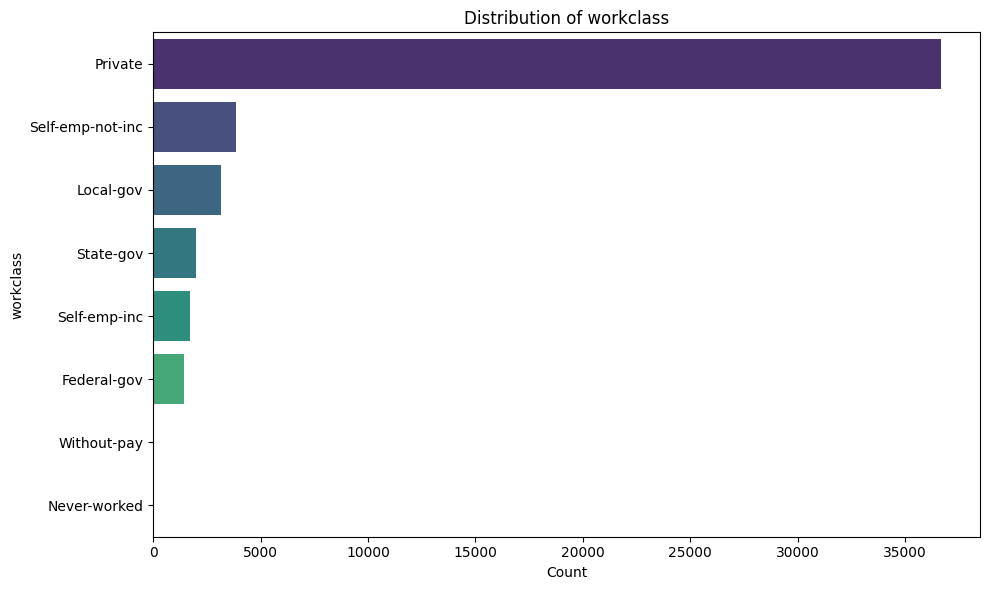


Analyzing categorical column: education


/tmp/ipython-input-2811231084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


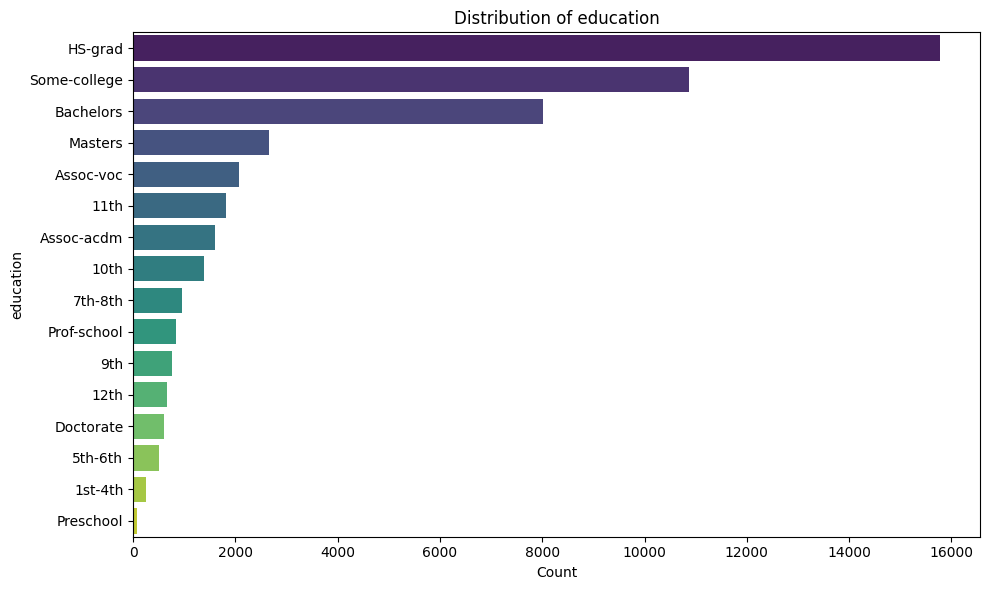


Analyzing categorical column: marital-status


/tmp/ipython-input-2811231084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


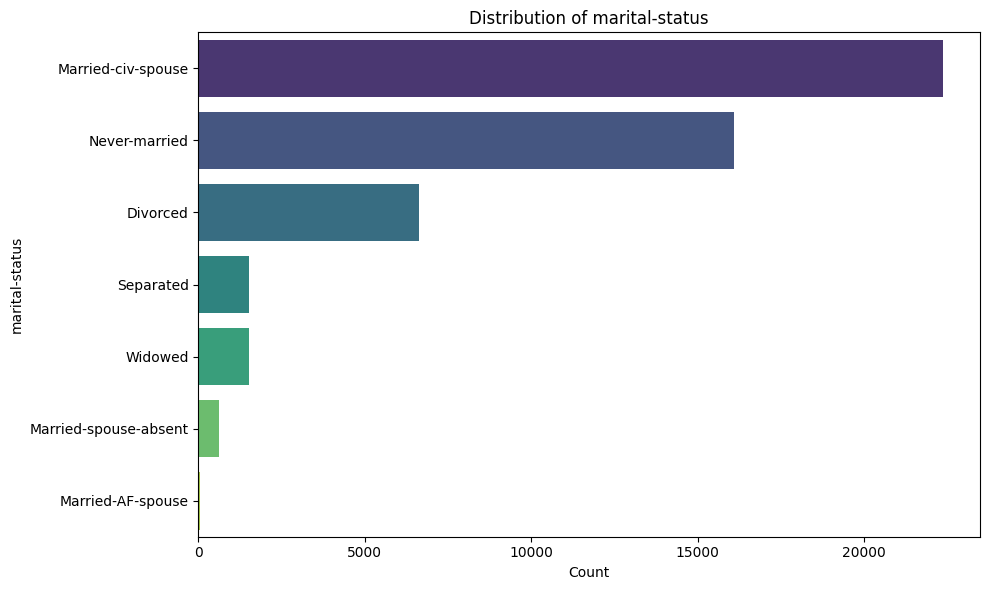


Analyzing categorical column: occupation


/tmp/ipython-input-2811231084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


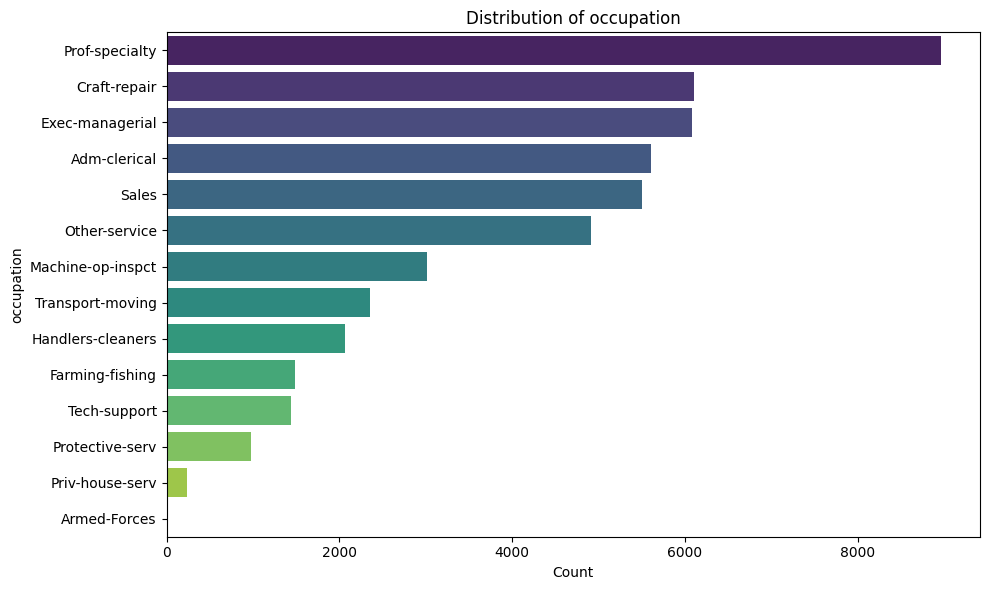


Analyzing categorical column: relationship


/tmp/ipython-input-2811231084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


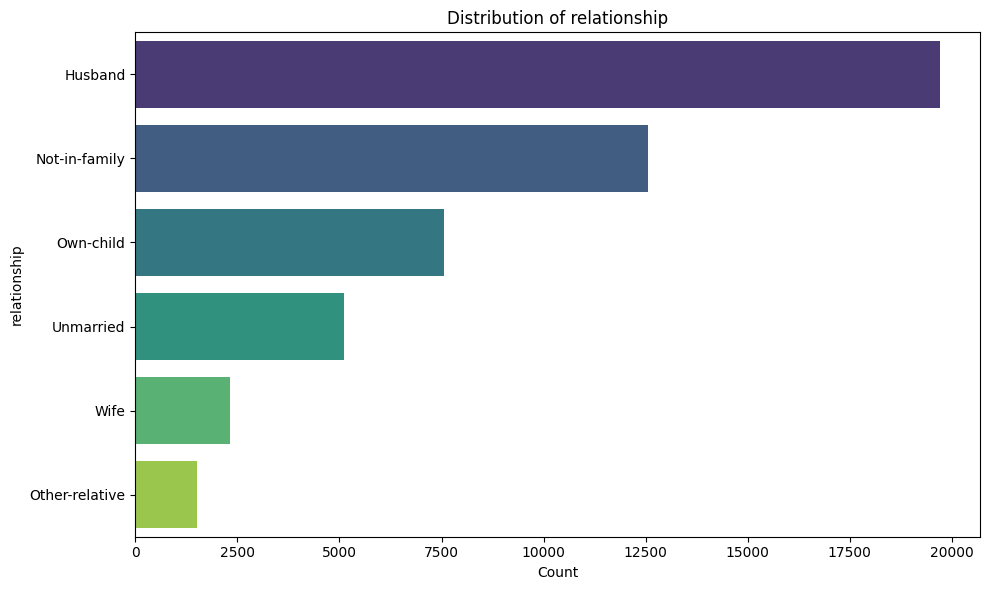


Analyzing categorical column: race


/tmp/ipython-input-2811231084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


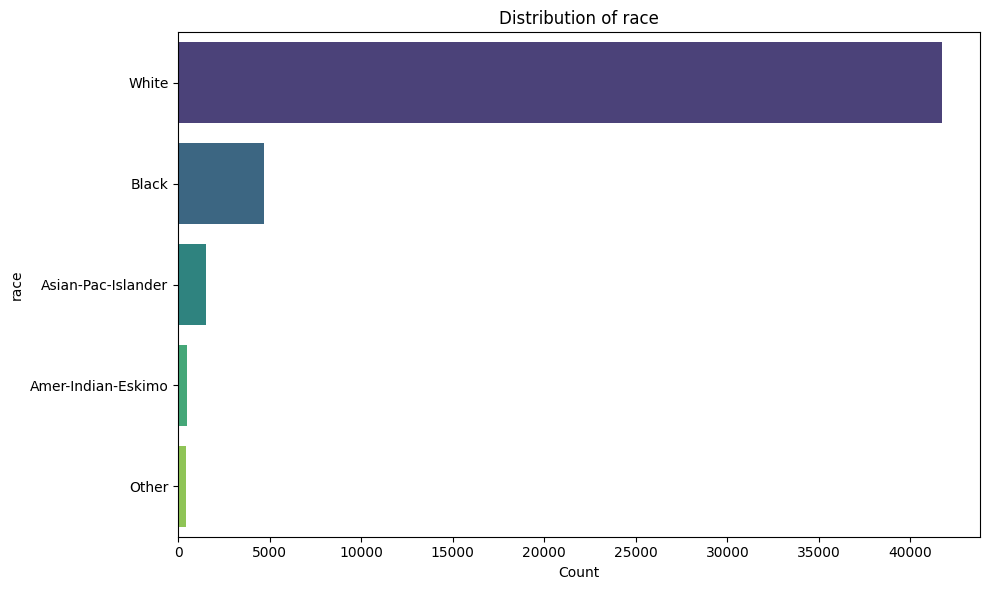


Analyzing categorical column: sex


/tmp/ipython-input-2811231084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


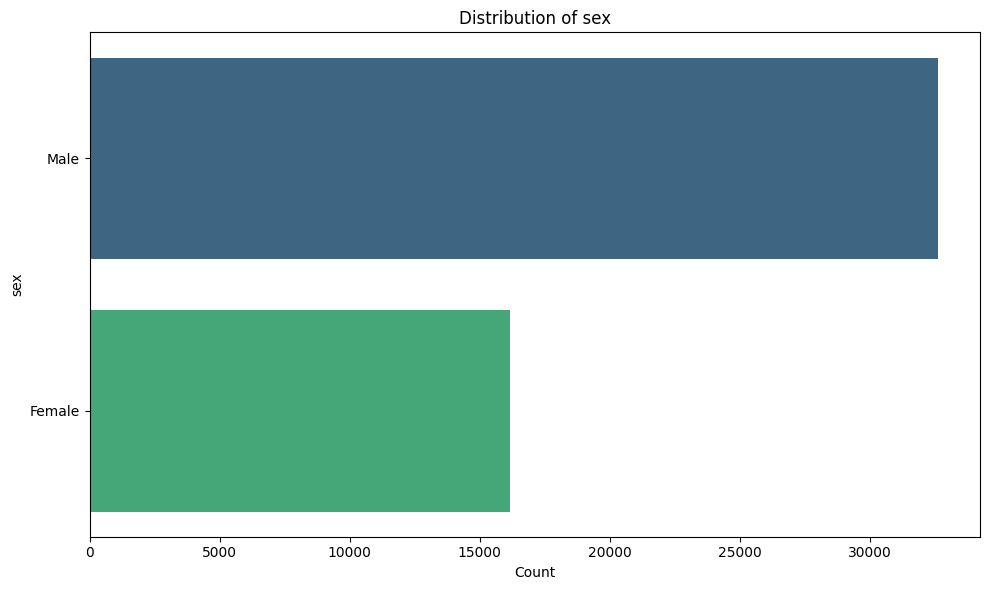


Analyzing categorical column: native-country


/tmp/ipython-input-2811231084.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


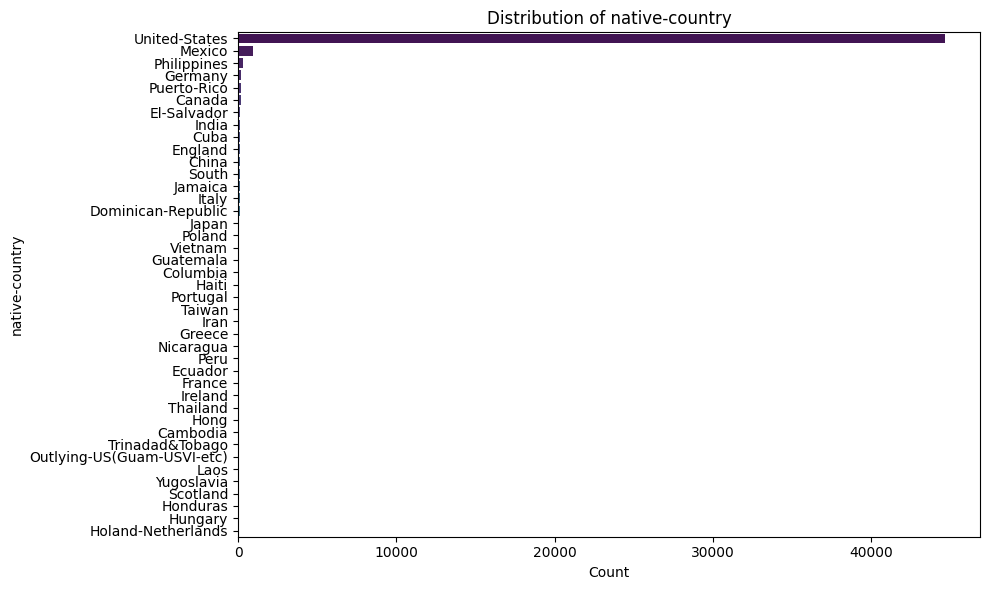

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nAnalyzing categorical column: {col}")
    plt.figure(figsize=(10, 6))
    sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Summary Statistics for Numerical Features (X)

Let's display the descriptive statistics for numerical columns in the `X` DataFrame.

In [ ]:
display(X.describe())

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48789.000000,4.878900e+04,48789.000000,48789.000000,48789.000000,48789.000000
mean,38.653139,1.896697e+05,10.078809,1080.239829,87.597368,40.425895
std,13.708426,1.056182e+05,2.570072,7455.980728,403.213066,12.392856
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781400e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376080e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


## Univariate Analysis of Numerical Features (X)

Let's visualize the distribution of numerical features using histograms and box plots.


Analyzing numerical column: age


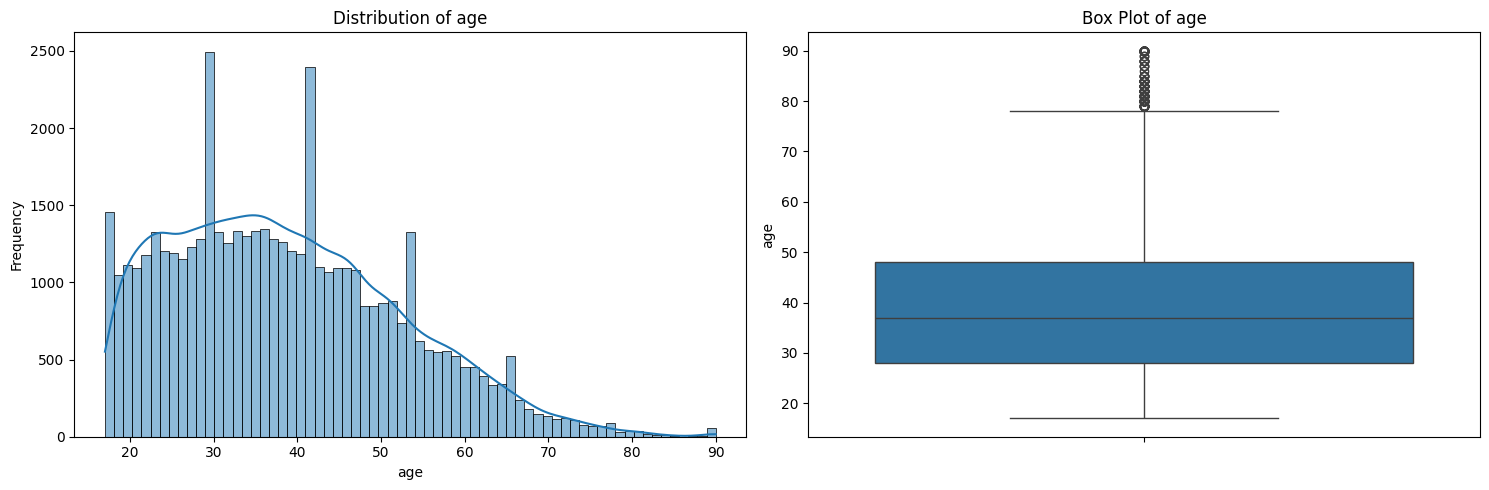


Analyzing numerical column: fnlwgt


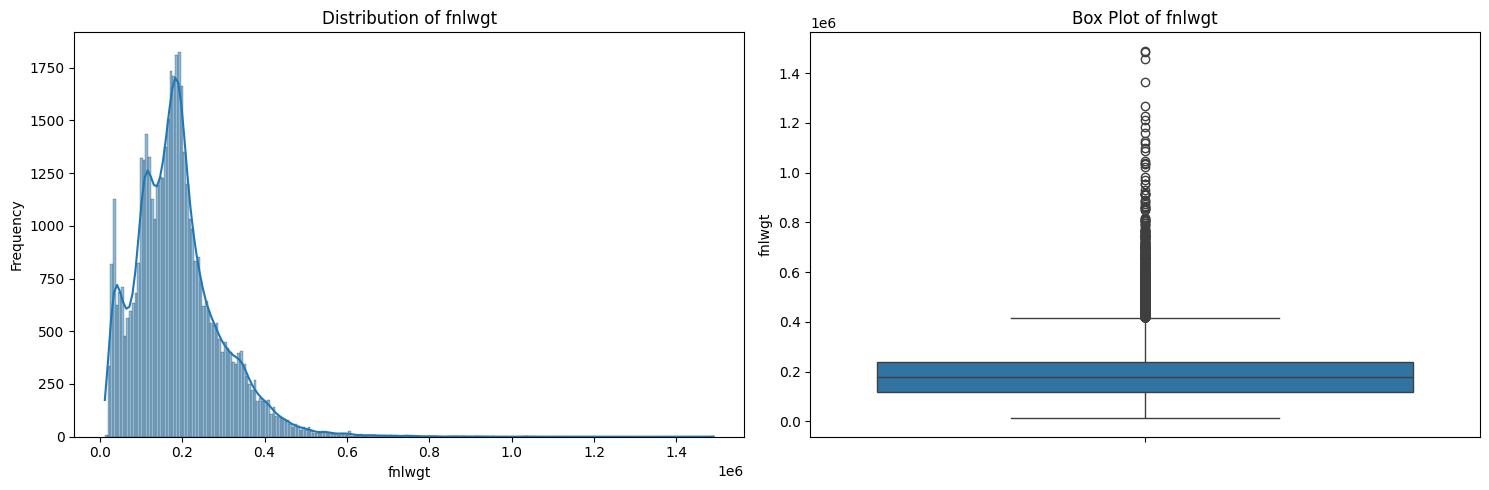


Analyzing numerical column: education-num


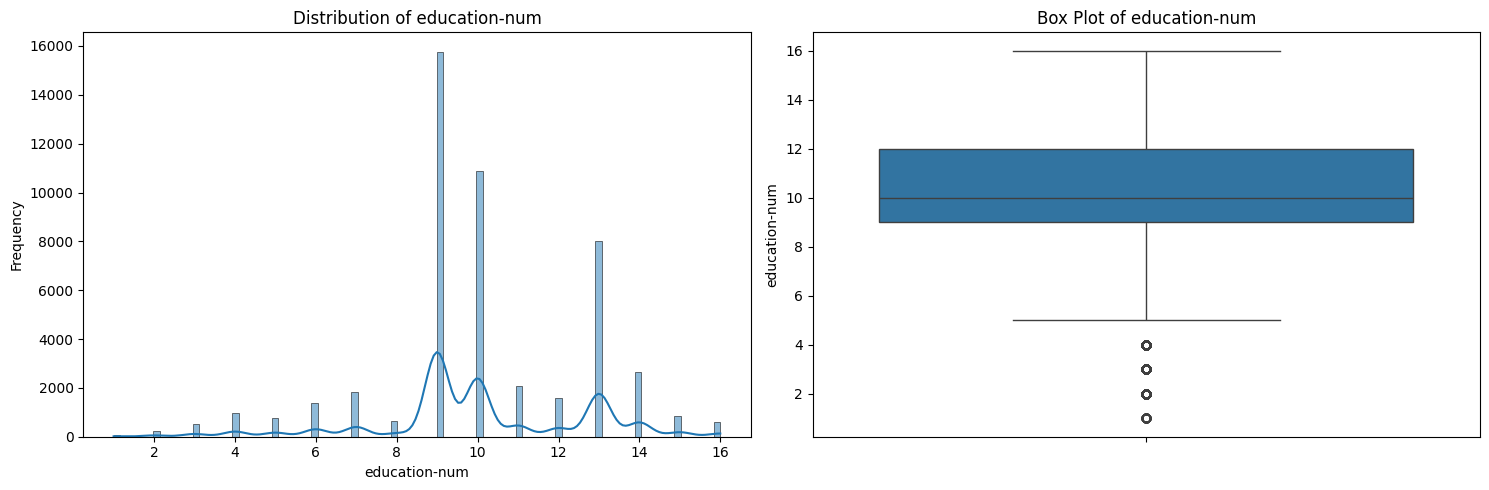


Analyzing numerical column: capital-gain


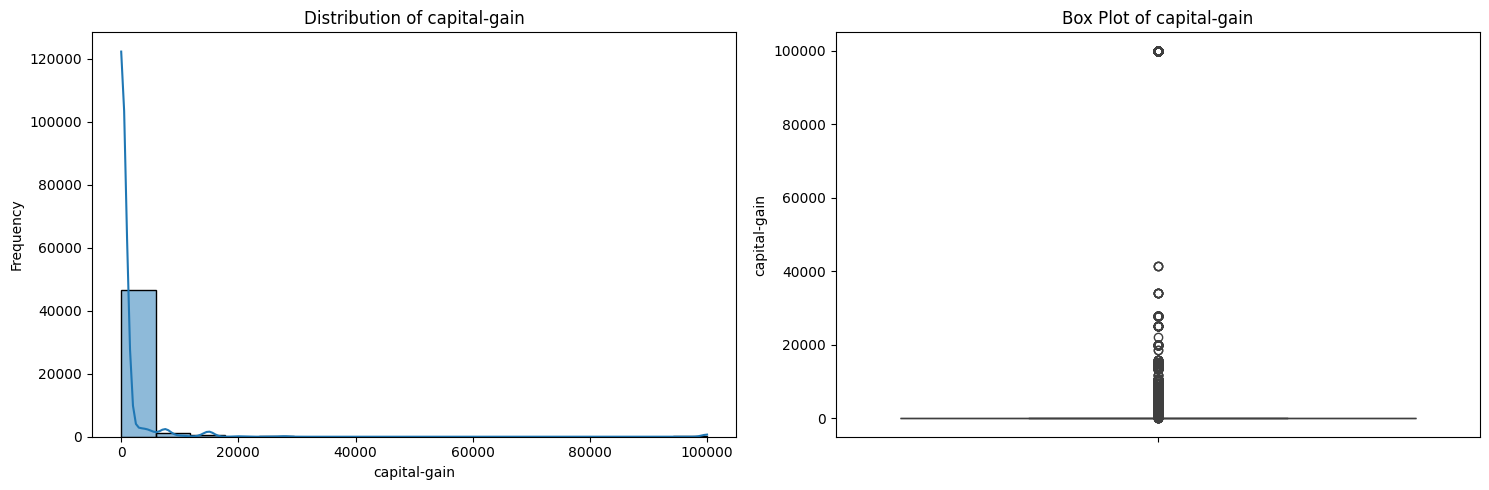


Analyzing numerical column: capital-loss


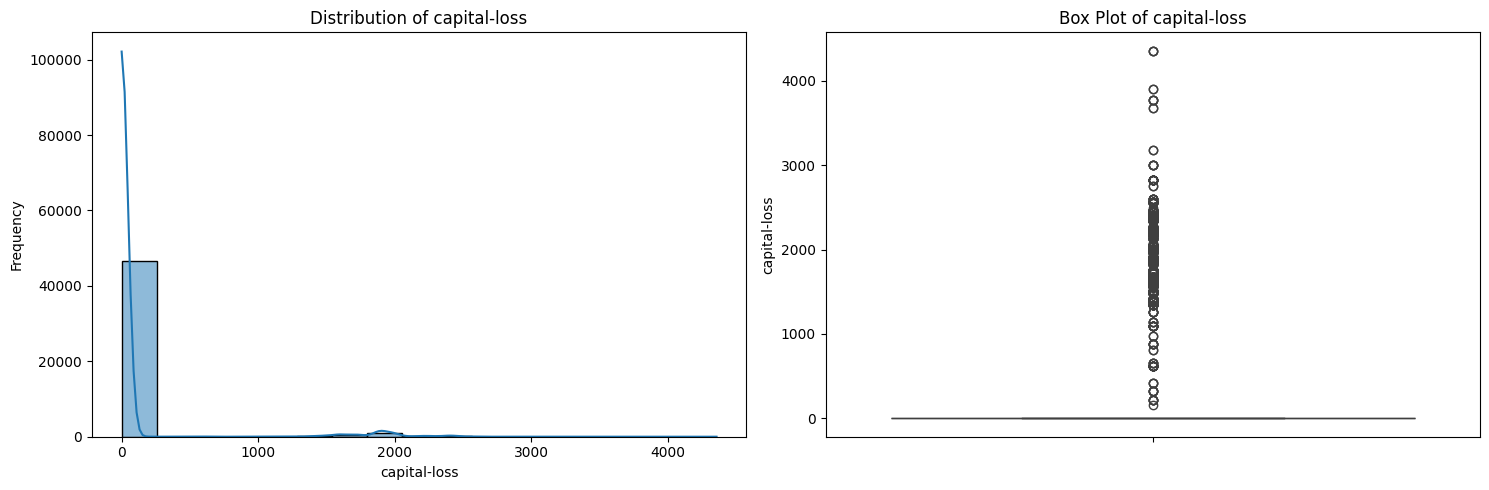


Analyzing numerical column: hours-per-week


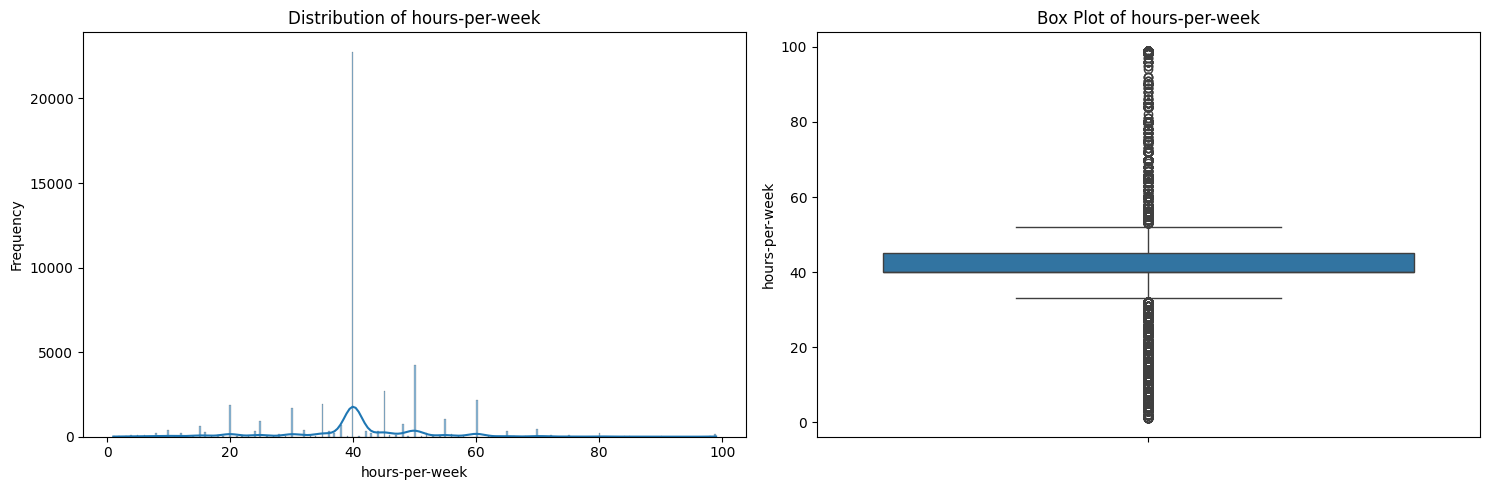

In [ ]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    print(f"\nAnalyzing numerical column: {col}")

    plt.figure(figsize=(15, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(X[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=X[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

## Univariate Analysis of Target Variable (y) - 'income'

Let's visualize the distribution of the 'income' variable using a count plot and display its unique values and their counts.

Unique values and their counts in the 'income' variable:
income
<=50K    37108
>50K     11681
Name: count, dtype: int64


/tmp/ipython-input-4077671390.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y['income'], order=y['income'].value_counts().index, palette='coolwarm')


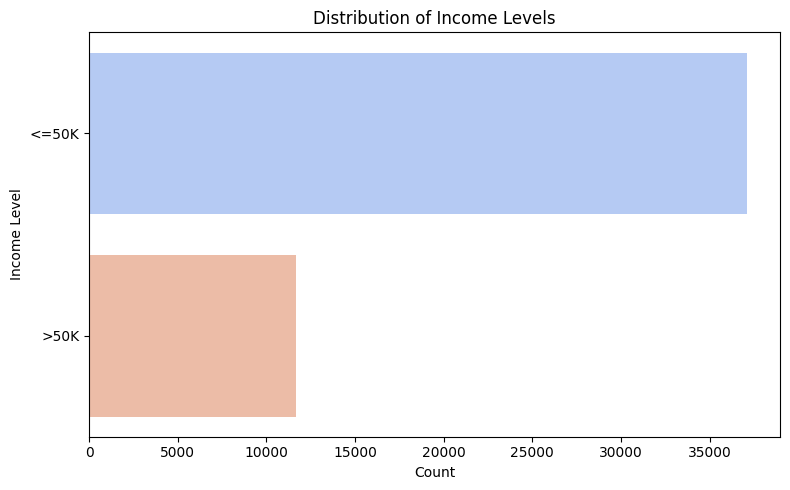

In [ ]:
print("Unique values and their counts in the 'income' variable:")
print(y['income'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(y=y['income'], order=y['income'].value_counts().index, palette='coolwarm')
plt.title('Distribution of Income Levels')
plt.xlabel('Count')
plt.ylabel('Income Level')
plt.tight_layout()
plt.show()

## Univariate Analysis of Unordered Categorical Features (X)

Let's visualize the distribution of unordered categorical features using count plots. These features are: `workclass`, `marital-status`, `occupation`, `relationship`, `race`, `sex`, and `native-country`.


Analyzing unordered categorical column: workclass


/tmp/ipython-input-650523968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


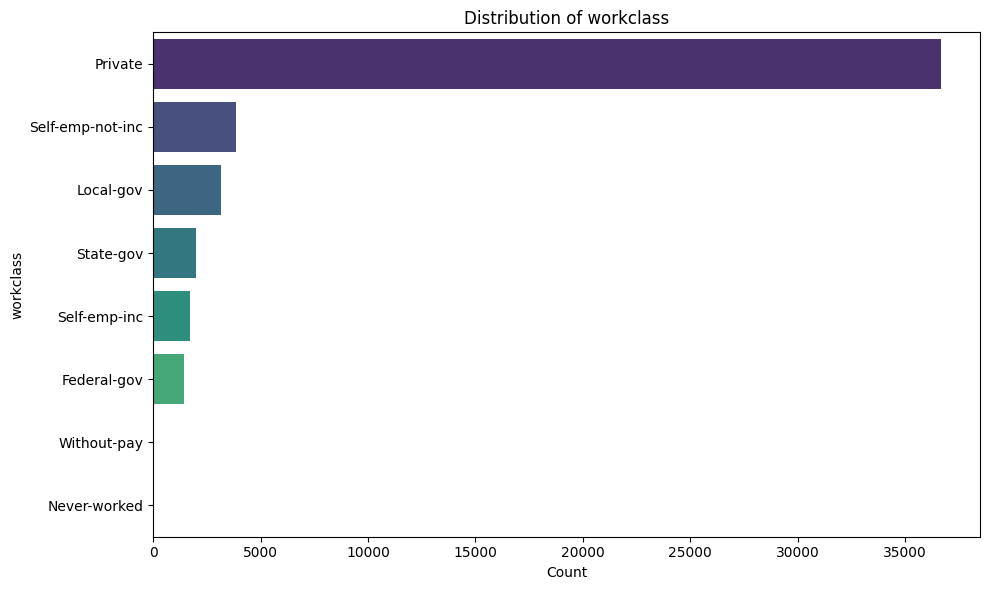


Analyzing unordered categorical column: marital-status


/tmp/ipython-input-650523968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


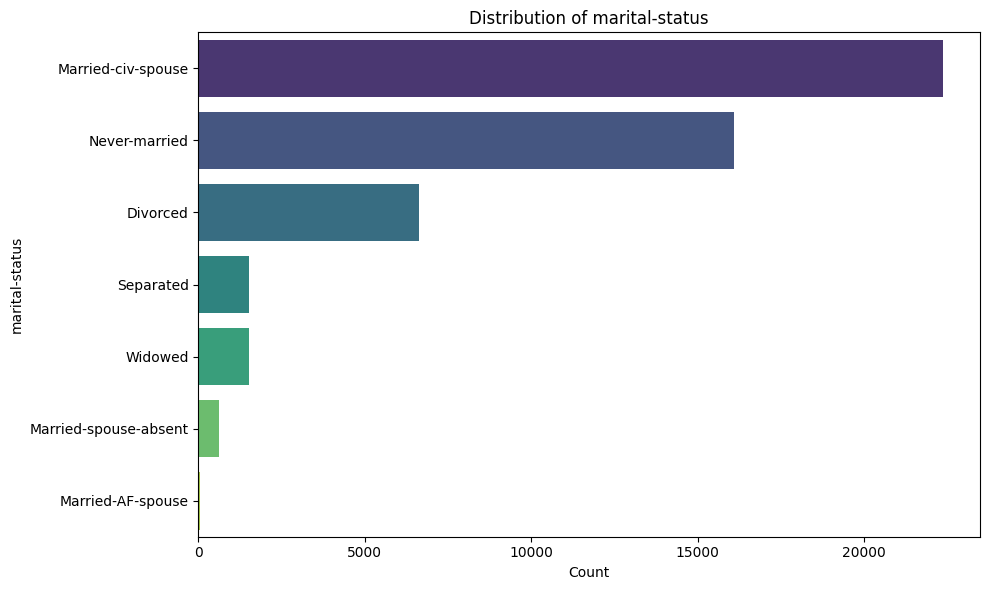


Analyzing unordered categorical column: occupation


/tmp/ipython-input-650523968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


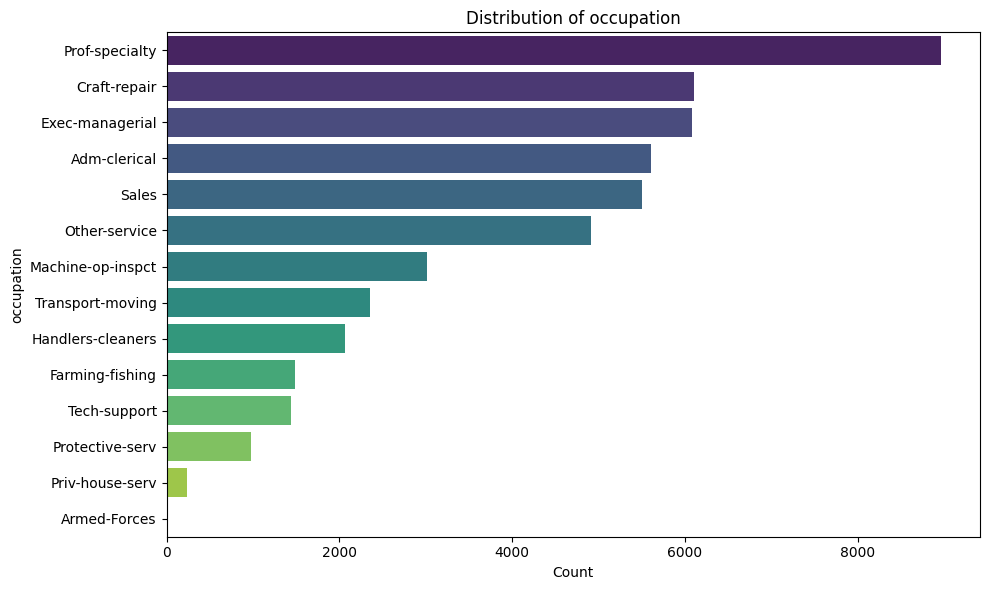


Analyzing unordered categorical column: relationship


/tmp/ipython-input-650523968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


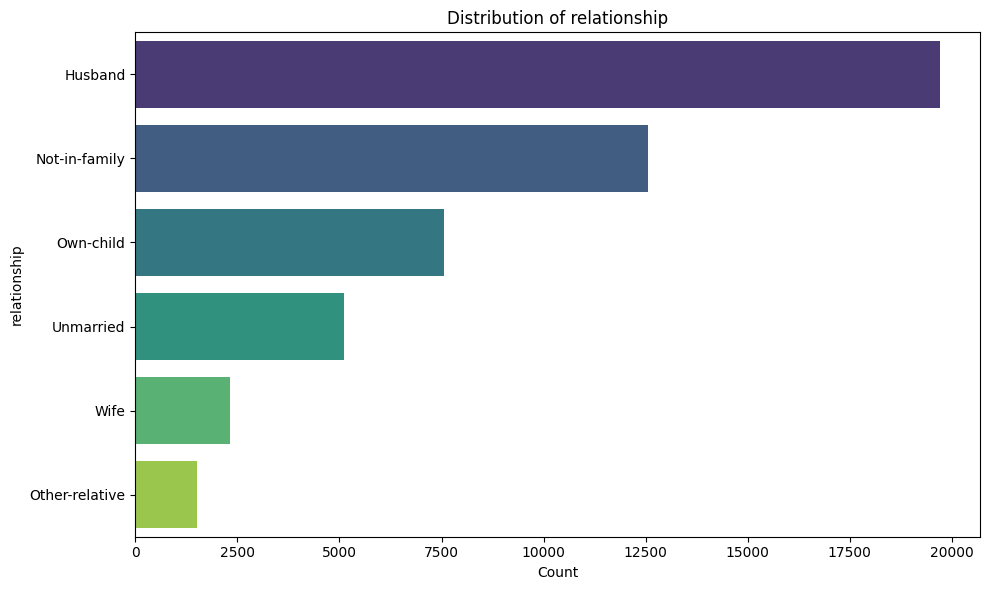


Analyzing unordered categorical column: race


/tmp/ipython-input-650523968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


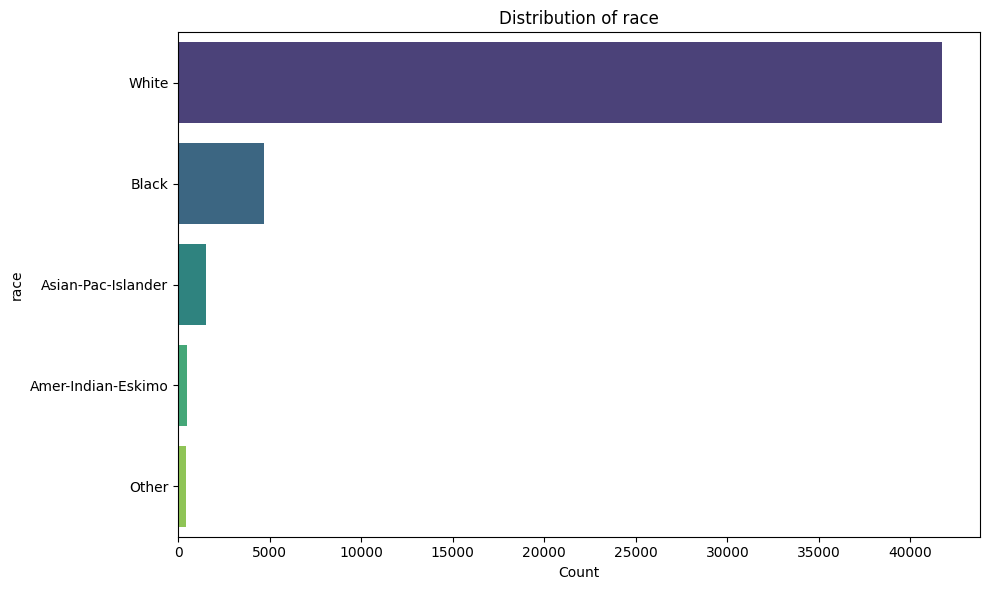


Analyzing unordered categorical column: sex


/tmp/ipython-input-650523968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


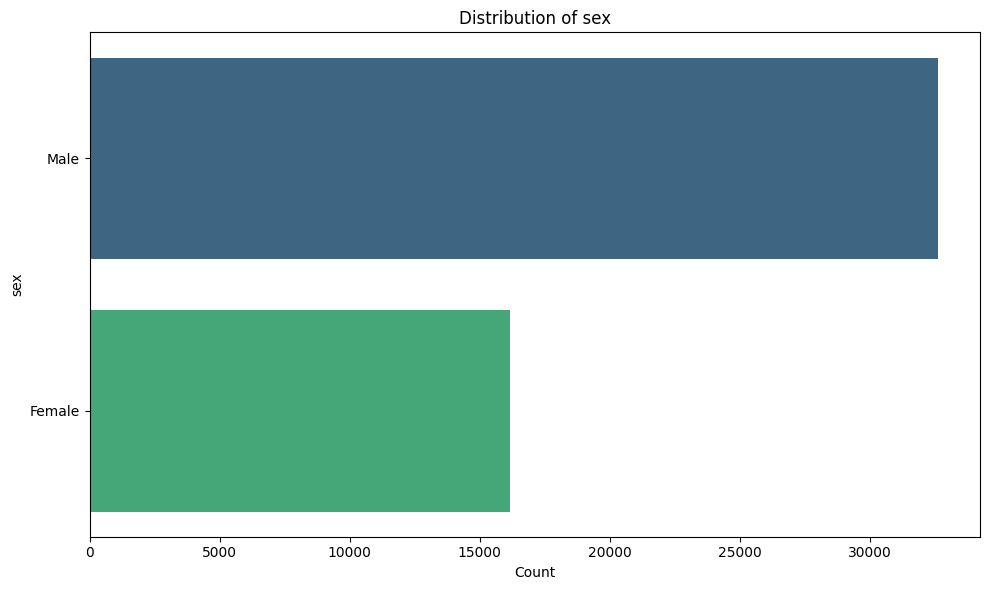


Analyzing unordered categorical column: native-country


/tmp/ipython-input-650523968.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')


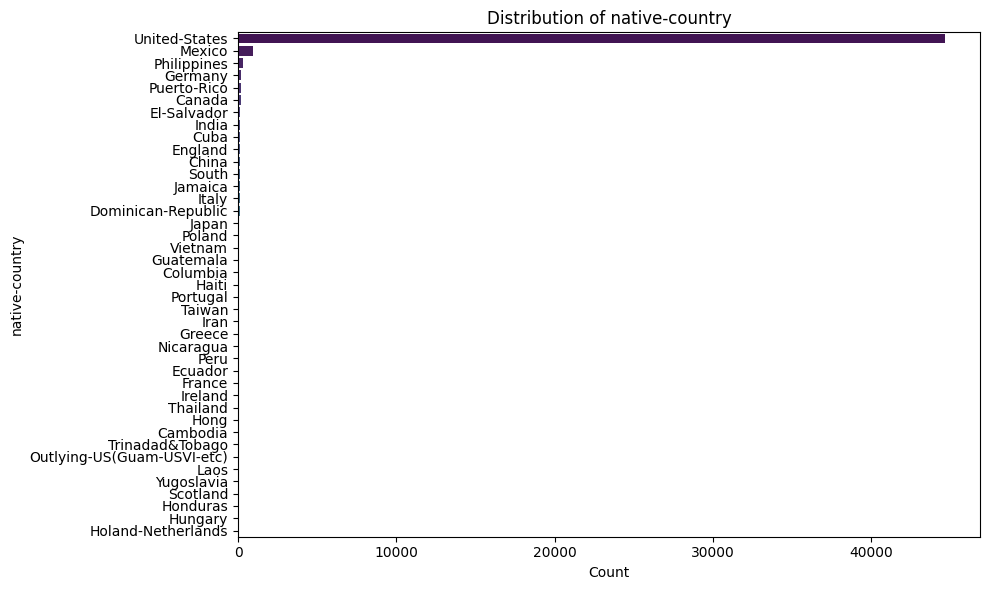

In [ ]:
unordered_categorical_cols = ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

for col in unordered_categorical_cols:
    print(f"\nAnalyzing unordered categorical column: {col}")
    plt.figure(figsize=(10, 6))
    sns.countplot(y=X[col], order=X[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Univariate Analysis of Ordered Categorical Features (X)

Let's visualize the distribution of ordered categorical features. The `education` column is a good example of an ordered categorical feature as it represents different levels of education.


Analyzing ordered categorical column: education


/tmp/ipython-input-766067943.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=X[col], order=education_order, palette='viridis')


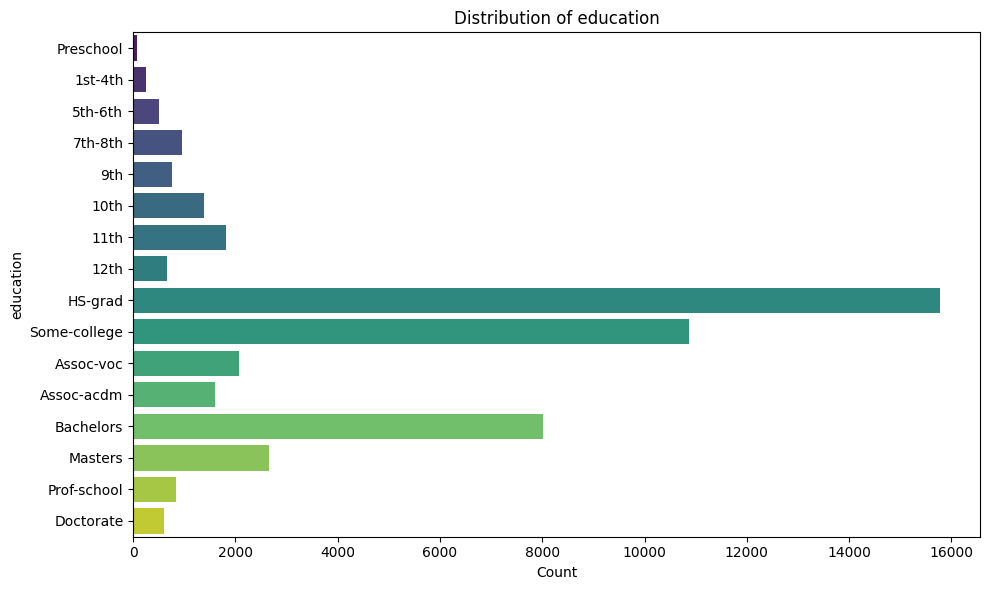

In [ ]:
ordered_categorical_cols = ['education']

for col in ordered_categorical_cols:
    print(f"\nAnalyzing ordered categorical column: {col}")
    plt.figure(figsize=(10, 6))
    # Order the categories for better visualization if there's a natural order
    education_order = [
        'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th',
        'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm', 'Bachelors',
        'Masters', 'Prof-school', 'Doctorate'
    ]
    sns.countplot(y=X[col], order=education_order, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

# Task
Visualize the distribution of each numerical feature in the `X` DataFrame, segmented by the 'income' levels from the `y` DataFrame, using histograms and box plots. Summarize the key insights.

## Segmented Analysis of Numerical Features

### Subtask:
Visualize the distribution of each numerical feature in the `X` DataFrame, segmented by the 'income' levels from the `y` DataFrame, using histograms and box plots.


**Reasoning**:
As per the instructions, I need to identify numerical columns, combine the X and y DataFrames, and then iterate through each numerical column to create segmented histograms and box plots based on the 'income' variable. This code block will perform these steps.




Analyzing numerical column: age by Income


/tmp/ipython-input-3170374996.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='income', y=col, palette='viridis')


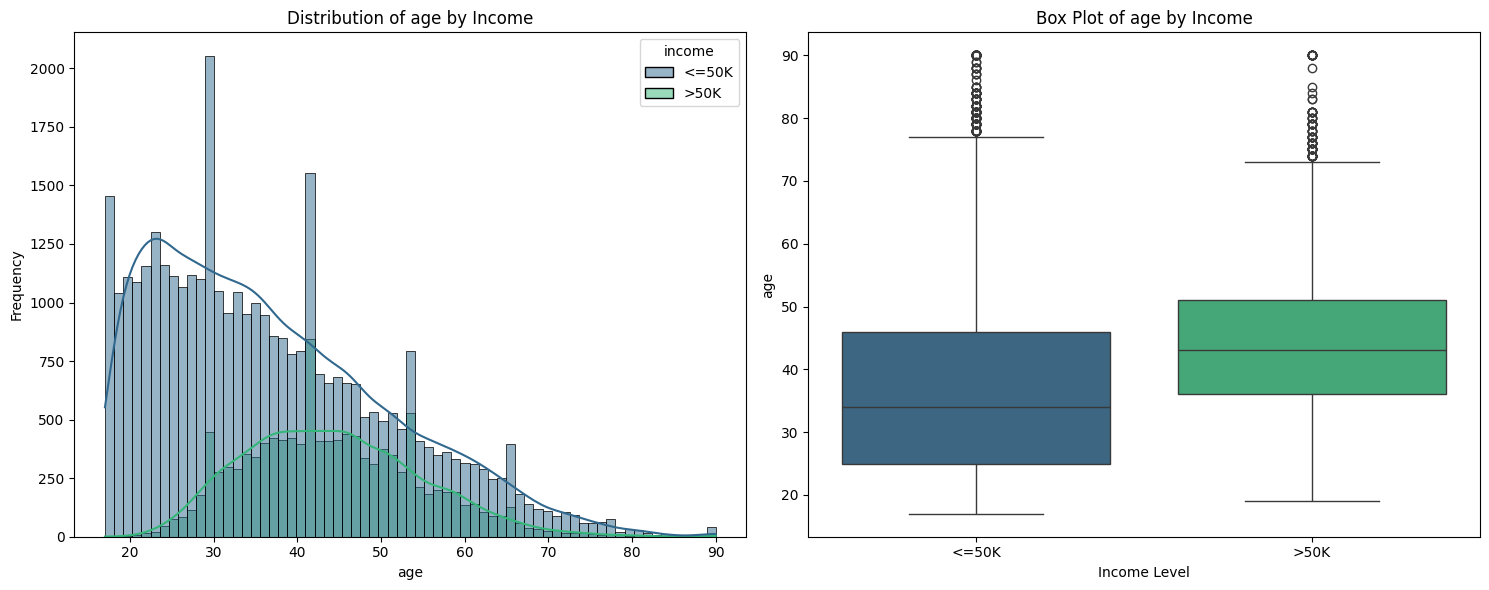


Analyzing numerical column: fnlwgt by Income


/tmp/ipython-input-3170374996.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='income', y=col, palette='viridis')


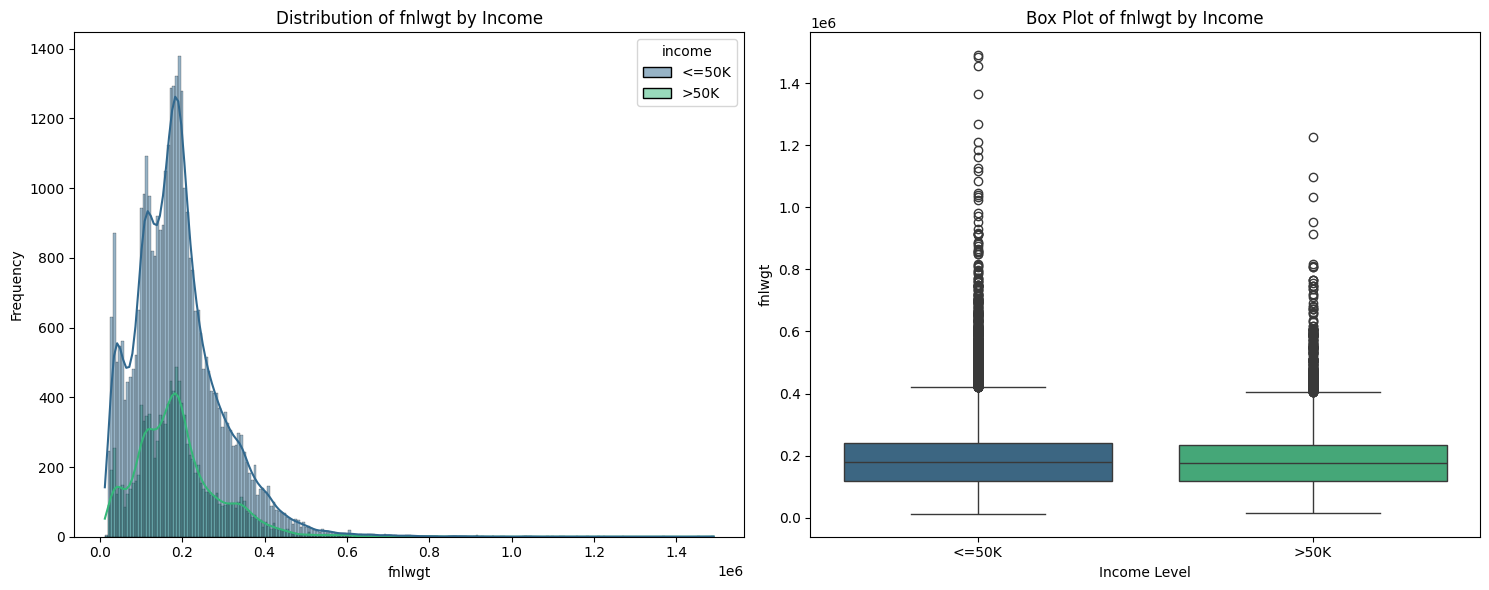


Analyzing numerical column: education-num by Income


/tmp/ipython-input-3170374996.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='income', y=col, palette='viridis')


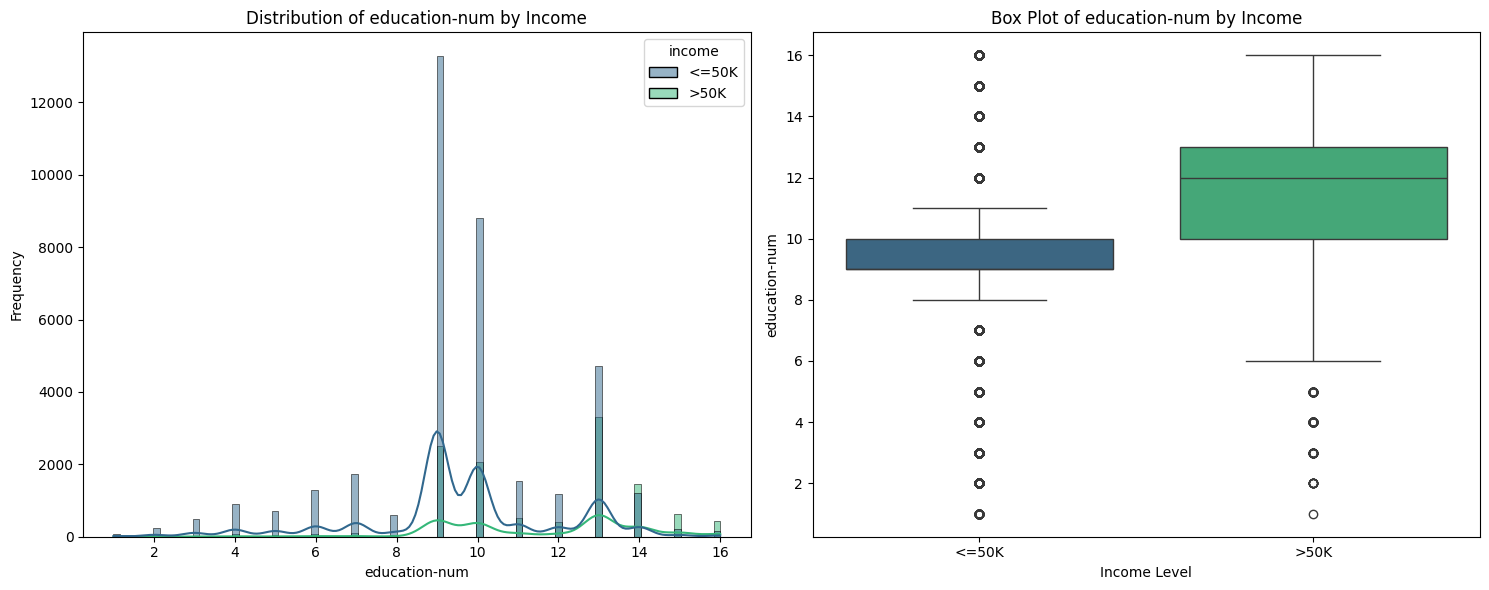


Analyzing numerical column: capital-gain by Income


/tmp/ipython-input-3170374996.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='income', y=col, palette='viridis')


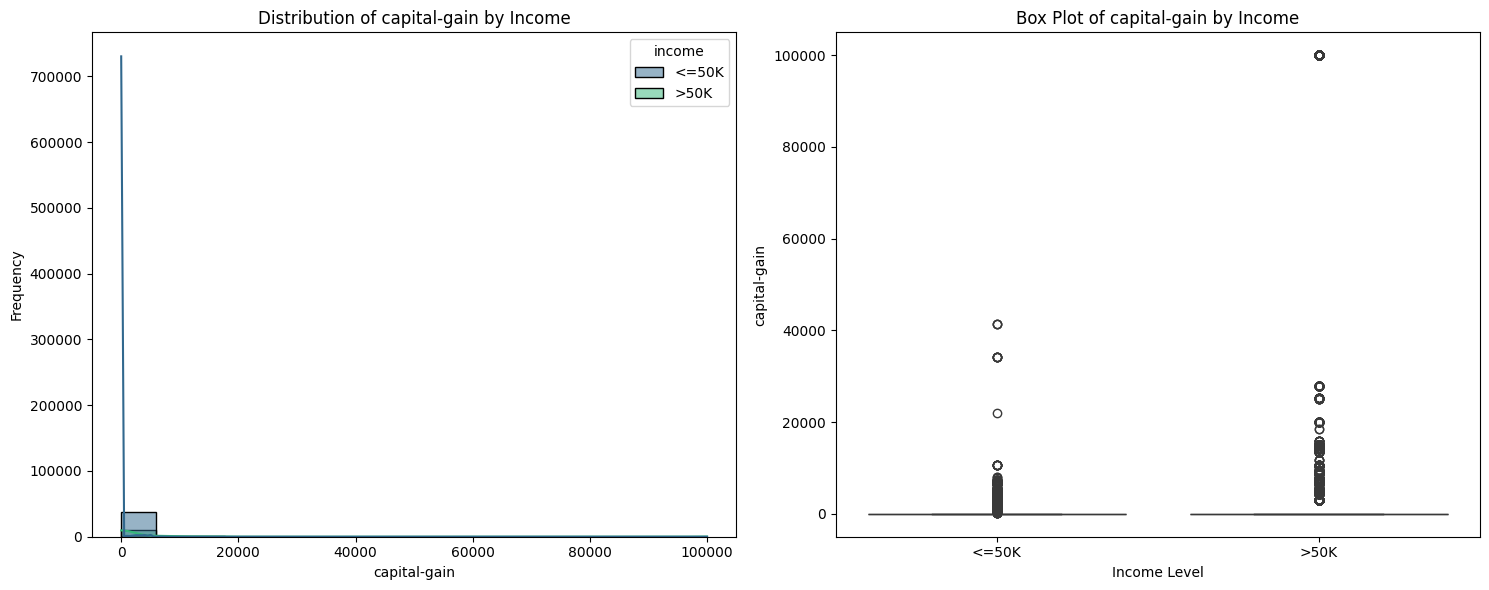


Analyzing numerical column: capital-loss by Income


/tmp/ipython-input-3170374996.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='income', y=col, palette='viridis')


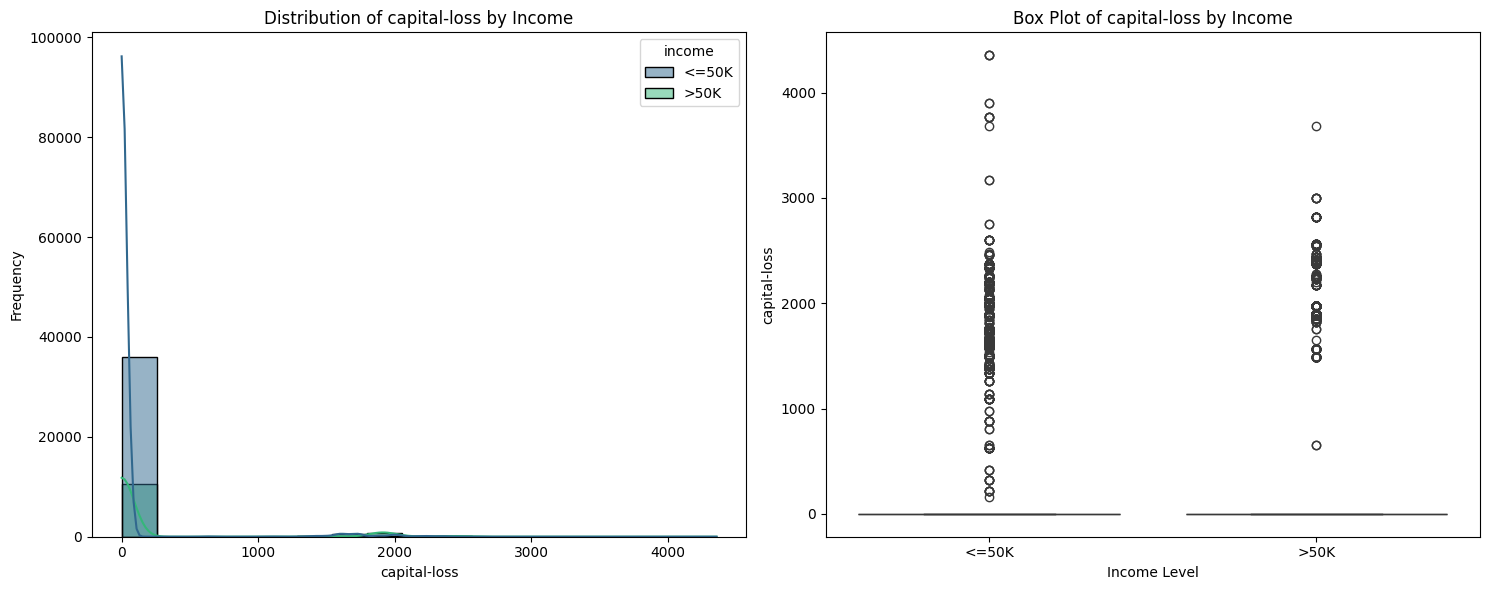


Analyzing numerical column: hours-per-week by Income


/tmp/ipython-input-3170374996.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined, x='income', y=col, palette='viridis')


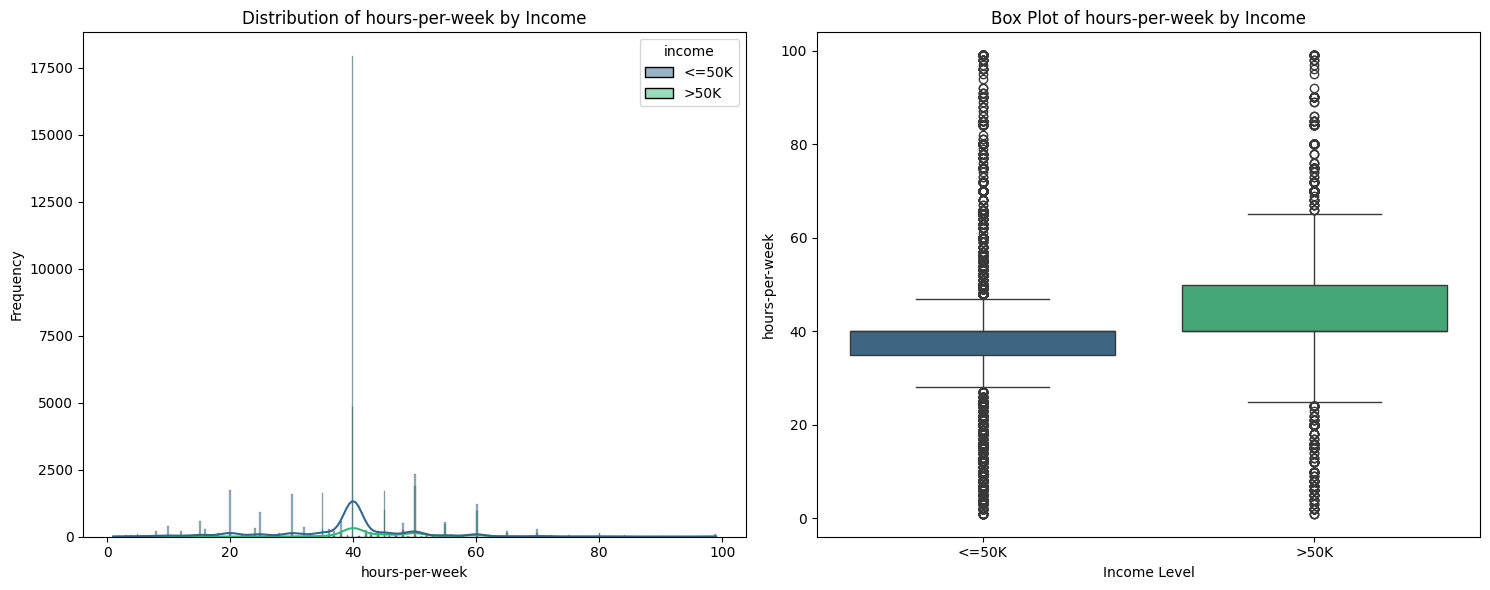

In [ ]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Concatenate X and y into a single DataFrame
df_combined = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)

for col in numerical_cols:
    print(f"\nAnalyzing numerical column: {col} by Income")

    plt.figure(figsize=(15, 6))

    # Histogram segmented by income
    plt.subplot(1, 2, 1)
    sns.histplot(data=df_combined, x=col, hue='income', kde=True, palette='viridis')
    plt.title(f'Distribution of {col} by Income')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Box Plot segmented by income
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_combined, x='income', y=col, palette='viridis')
    plt.title(f'Box Plot of {col} by Income')
    plt.xlabel('Income Level')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

**Reasoning**:
The previous code produced a FutureWarning related to the `palette` argument in `sns.boxplot`. To resolve this, I will explicitly set the `hue` parameter to 'income' and `legend=False` as suggested by the warning, ensuring proper color mapping and suppressing the warning.




Analyzing numerical column: age by Income


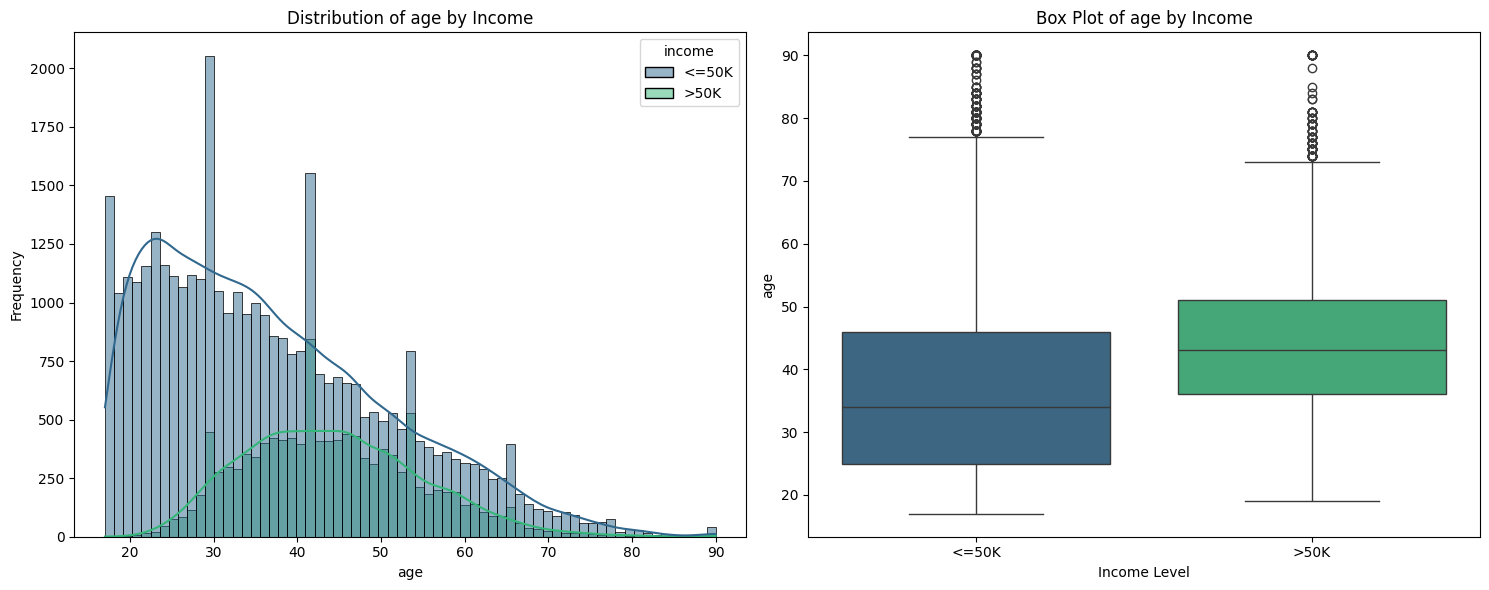


Analyzing numerical column: fnlwgt by Income


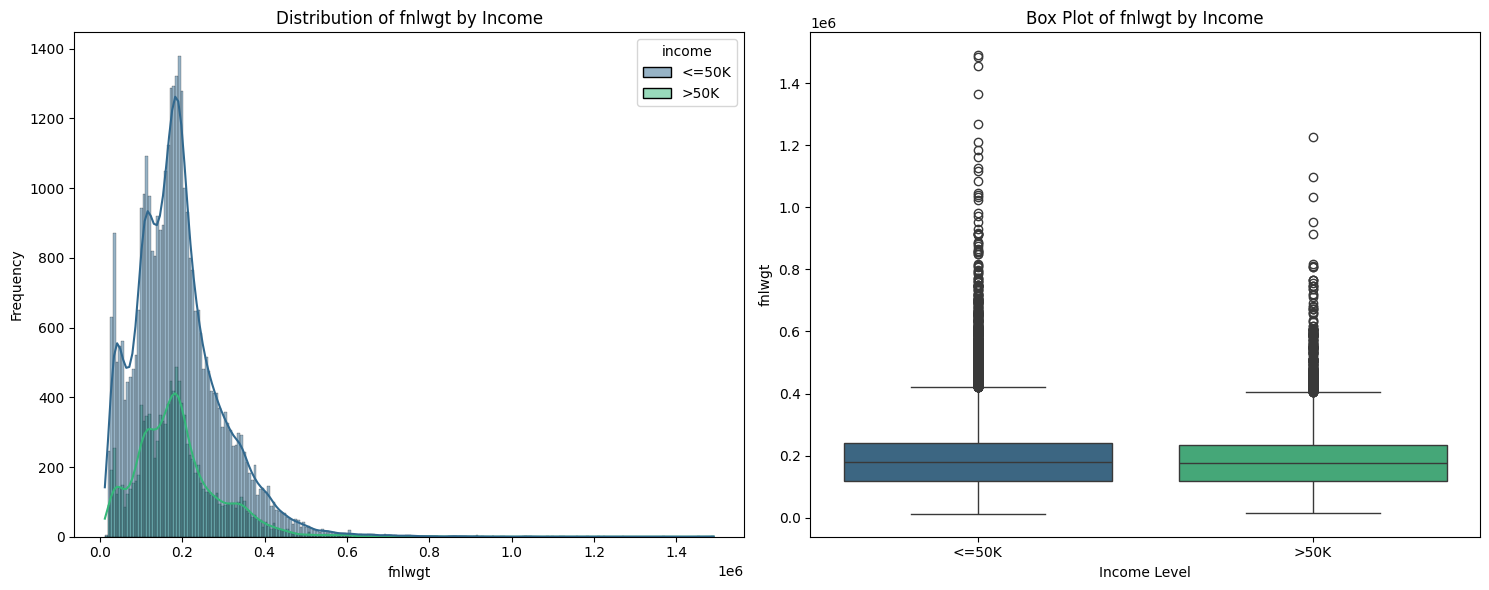


Analyzing numerical column: education-num by Income


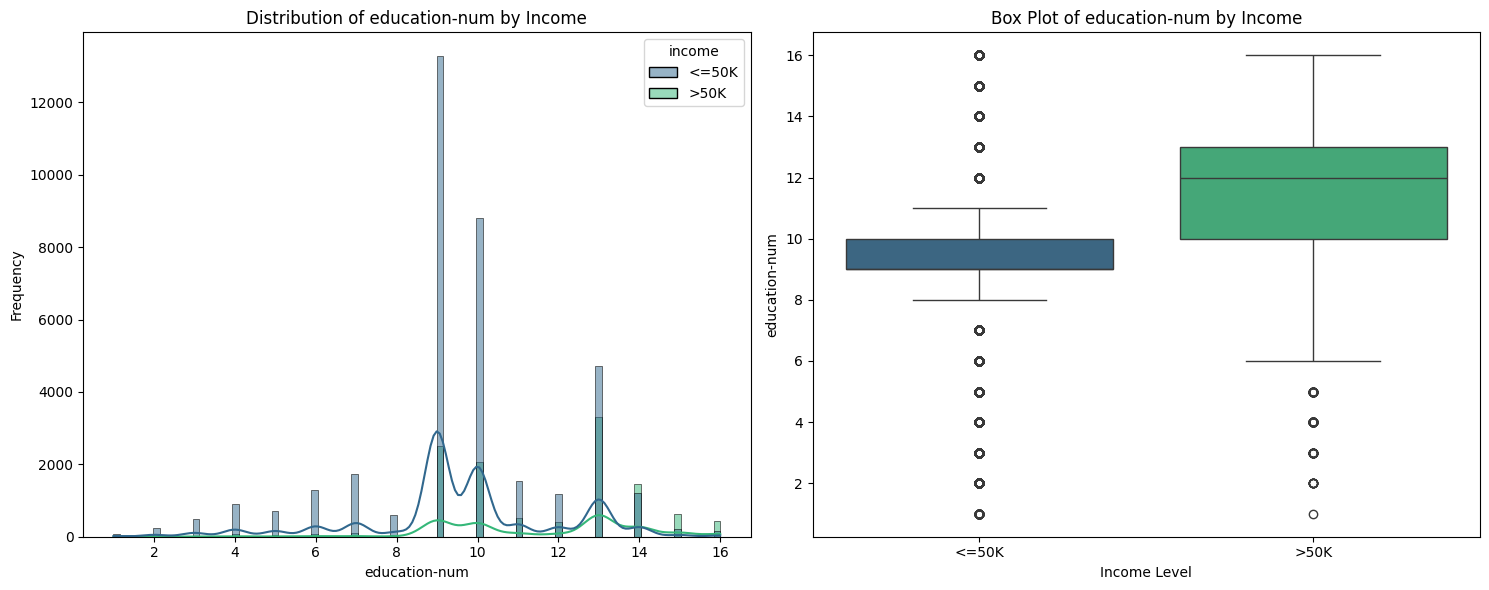


Analyzing numerical column: capital-gain by Income


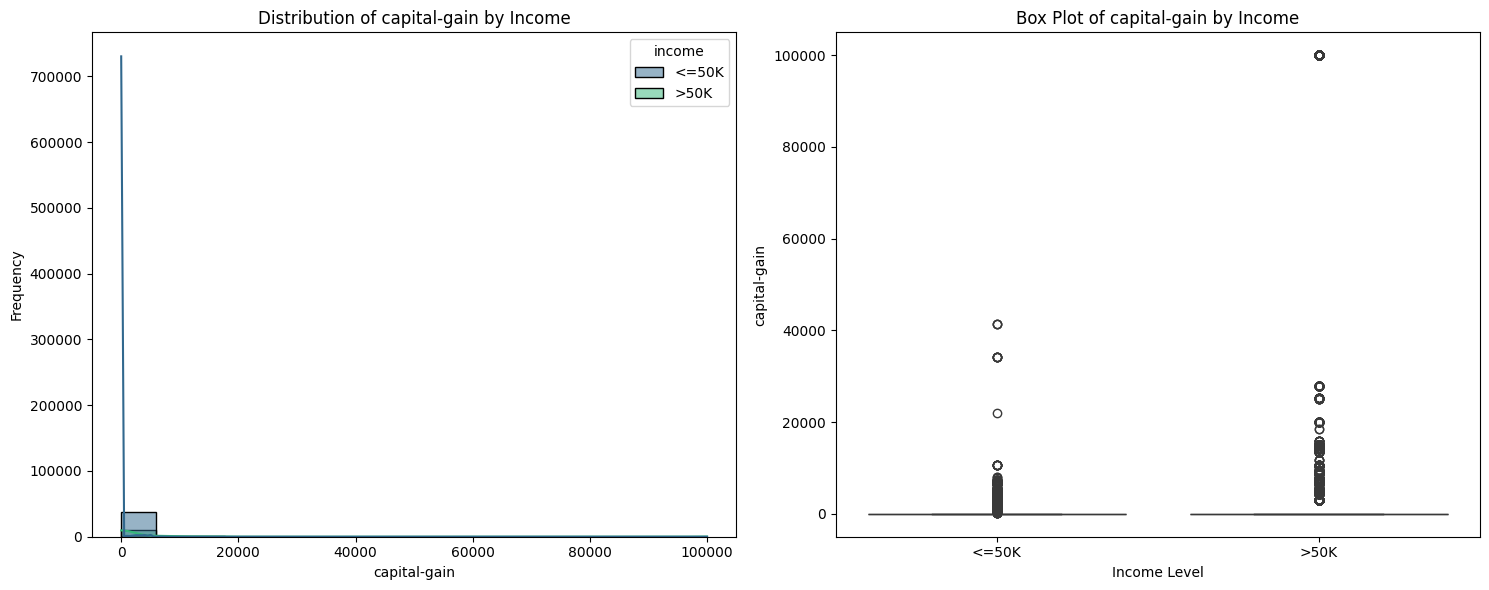


Analyzing numerical column: capital-loss by Income


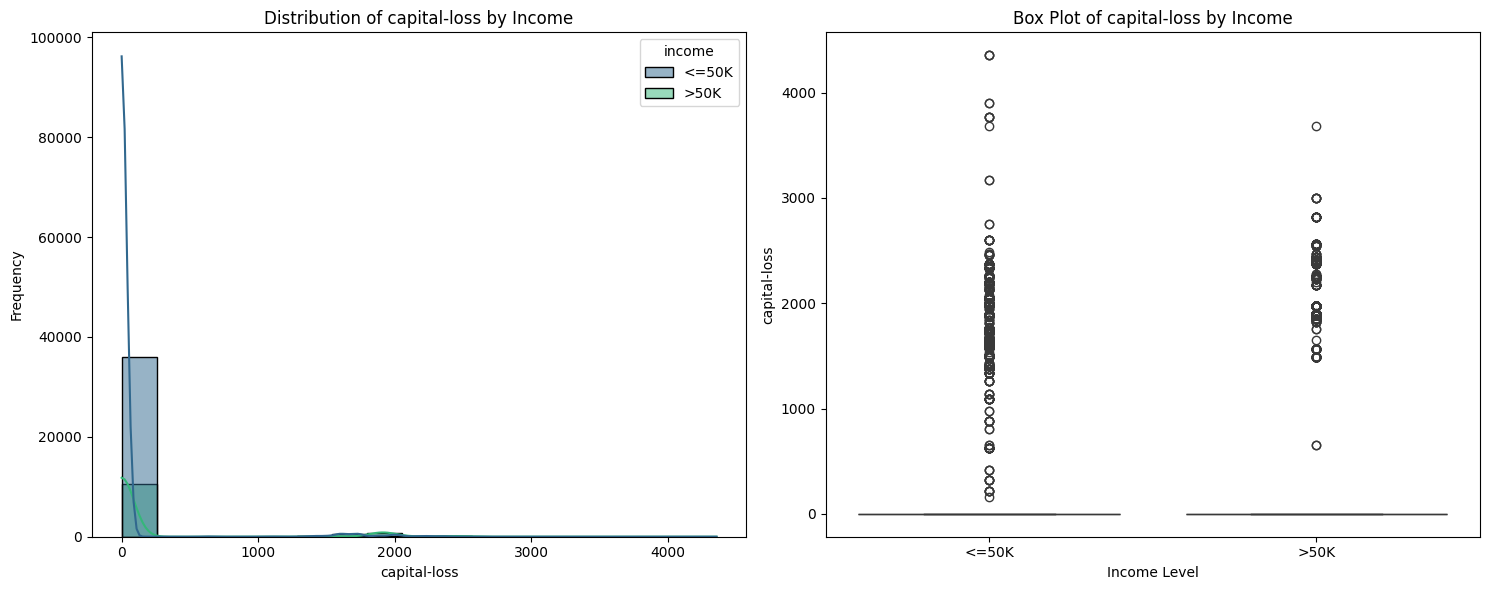


Analyzing numerical column: hours-per-week by Income


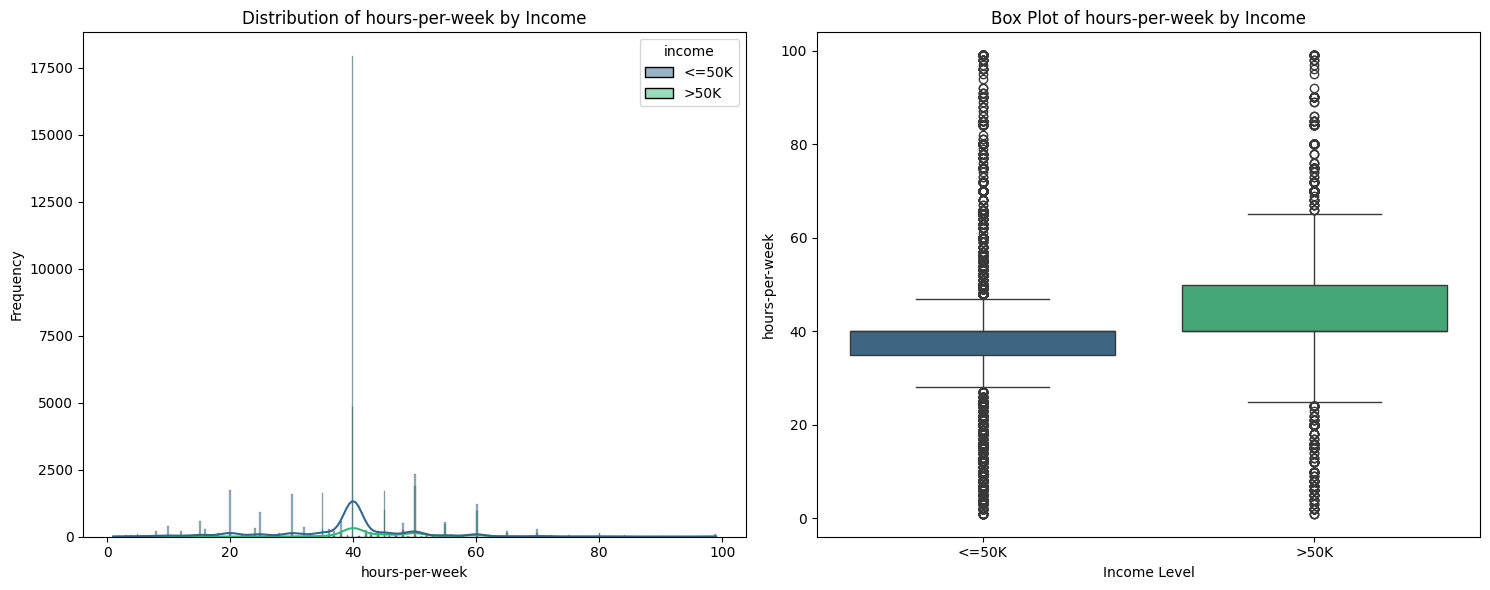

In [ ]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Concatenate X and y into a single DataFrame
df_combined = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)

for col in numerical_cols:
    print(f"\nAnalyzing numerical column: {col} by Income")

    plt.figure(figsize=(15, 6))

    # Histogram segmented by income
    plt.subplot(1, 2, 1)
    sns.histplot(data=df_combined, x=col, hue='income', kde=True, palette='viridis')
    plt.title(f'Distribution of {col} by Income')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Box Plot segmented by income
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df_combined, x='income', y=col, hue='income', palette='viridis', legend=False)
    plt.title(f'Box Plot of {col} by Income')
    plt.xlabel('Income Level')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

### Summary of Insights from Segmented Numerical Features

Based on the segmented histograms and box plots of numerical features by income level, several key insights can be observed:

*   **Age:** Individuals earning >50K generally appear to be older than those earning <=50K. The distribution for higher earners is shifted towards higher ages, and the median age for >50K income is notably higher.
*   **fnlwgt (Final Weight):** The distribution of `fnlwgt` appears to be similar across both income groups. This suggests that `fnlwgt` might not be a strong differentiator for income level, as its primary purpose is to assign a weight to each individual to ensure that demographic characteristics in the dataset align with those from the census.
*   **education-num (Years of Education):** There is a clear positive correlation between years of education and income. Individuals with higher `education-num` values are much more likely to earn >50K. The box plot for >50K income shows a significantly higher median and a tighter distribution around higher education levels.
*   **capital-gain:** A substantial portion of the population has zero capital gain. However, individuals with >50K income show a higher frequency and magnitude of positive capital gains compared to those with <=50K income, indicating that capital gains play a role in achieving higher income brackets.
*   **capital-loss:** Similar to capital gain, most individuals have zero capital loss. For those with capital losses, the distribution doesn't show a strong differentiation between income groups, although higher income individuals might experience slightly higher capital losses.
*   **hours-per-week:** People earning >50K tend to work more hours per week. Both the histogram and box plot indicate a shift towards a higher number of working hours for the >50K income group, with a higher median and a more spread-out distribution at higher hour counts.

Overall, `age`, `education-num`, and `hours-per-week` show a strong relationship with income levels, with higher values generally associated with higher income. `capital-gain` also shows a noticeable difference, while `fnlwgt` and `capital-loss` appear less influential in distinguishing between income groups.

## Segmented Analysis of Categorical Features

### Subtask:
Visualize the distribution of each categorical feature in the `X` DataFrame, segmented by the 'income' levels from the `y` DataFrame.


**Reasoning**:
To visualize the segmented distributions, I need to identify the categorical columns from the `X` DataFrame and then combine `X` and `y` into a single DataFrame. This will allow `seaborn` to plot the distributions of each categorical feature, segmented by the 'income' levels using the `hue` parameter, as requested.




Analyzing categorical column: workclass by Income


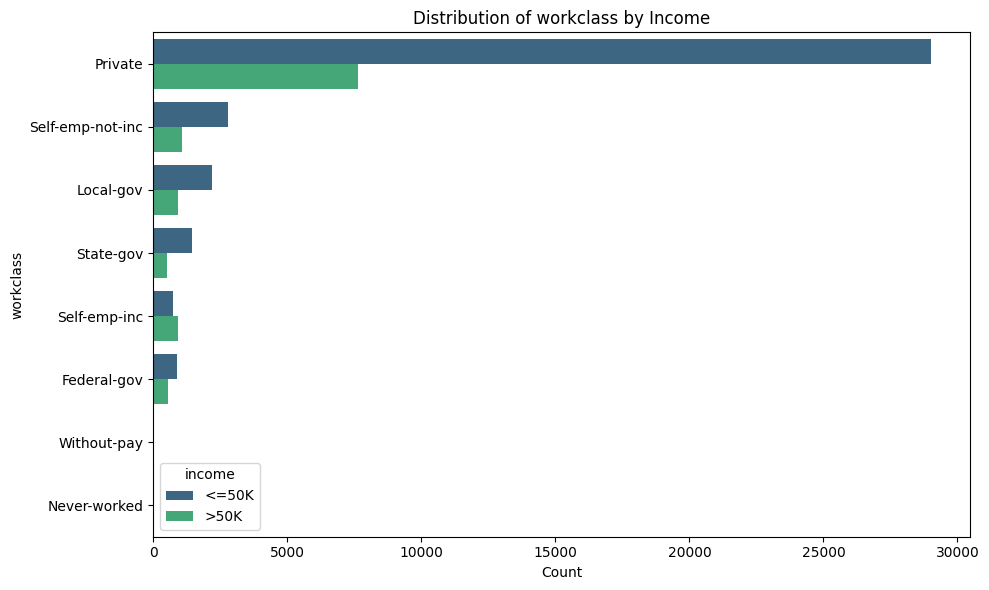


Analyzing categorical column: education by Income


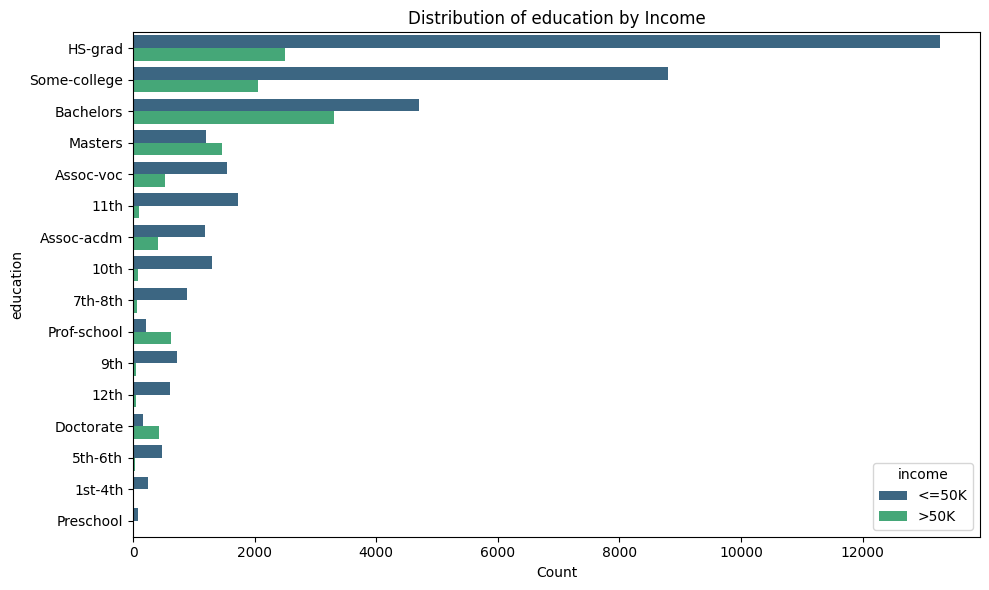


Analyzing categorical column: marital-status by Income


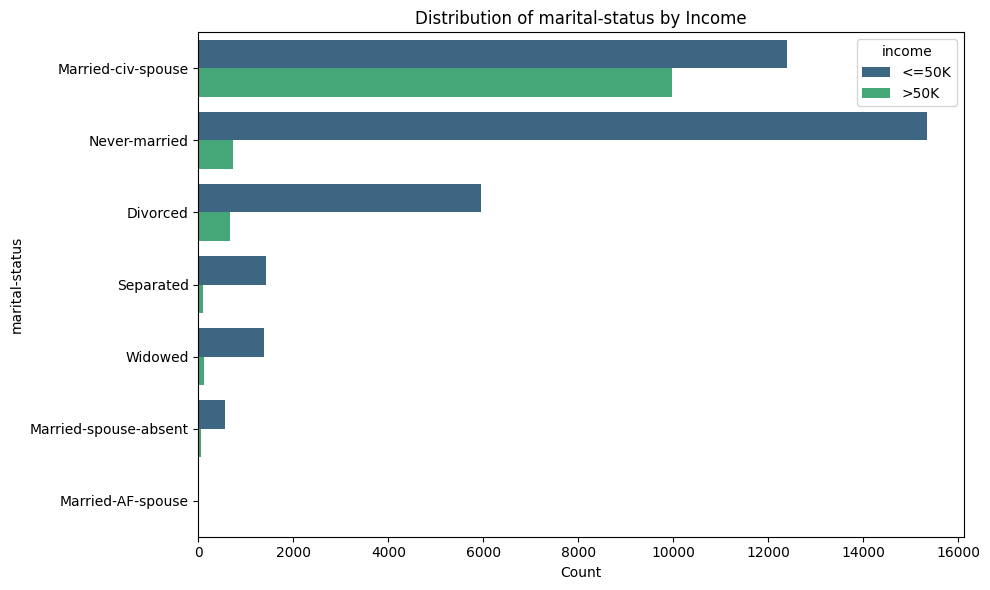


Analyzing categorical column: occupation by Income


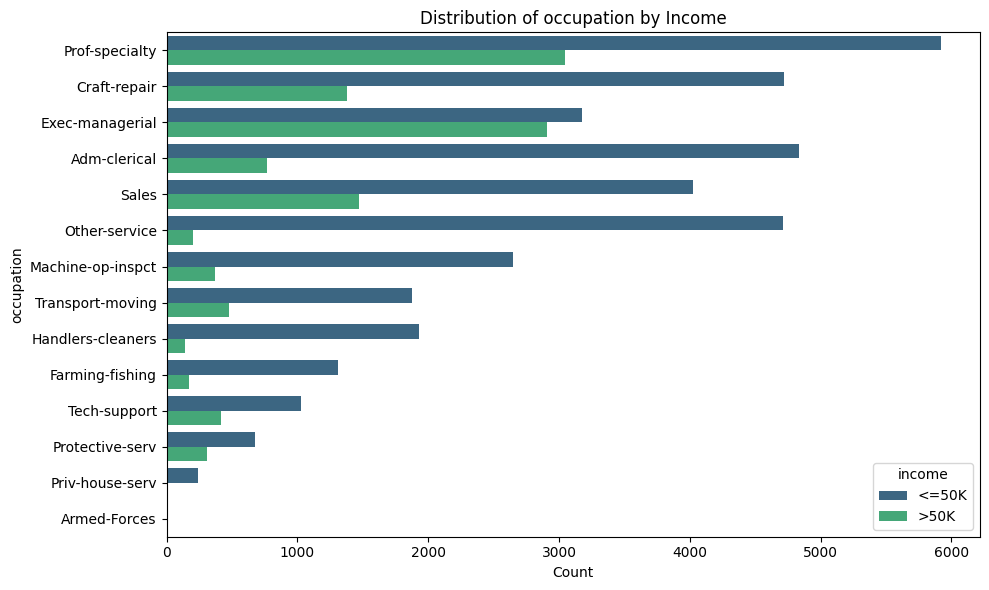


Analyzing categorical column: relationship by Income


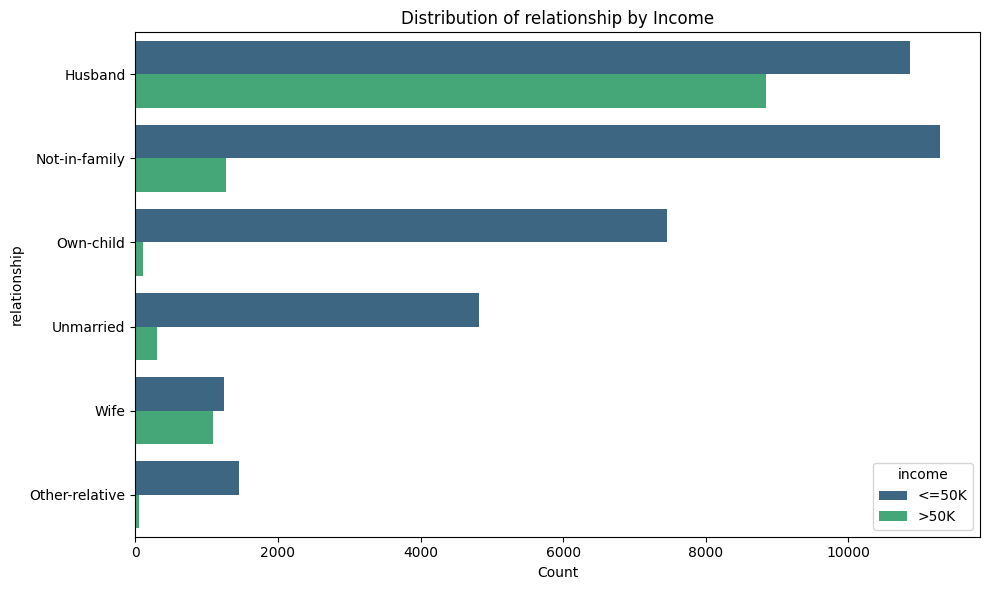


Analyzing categorical column: race by Income


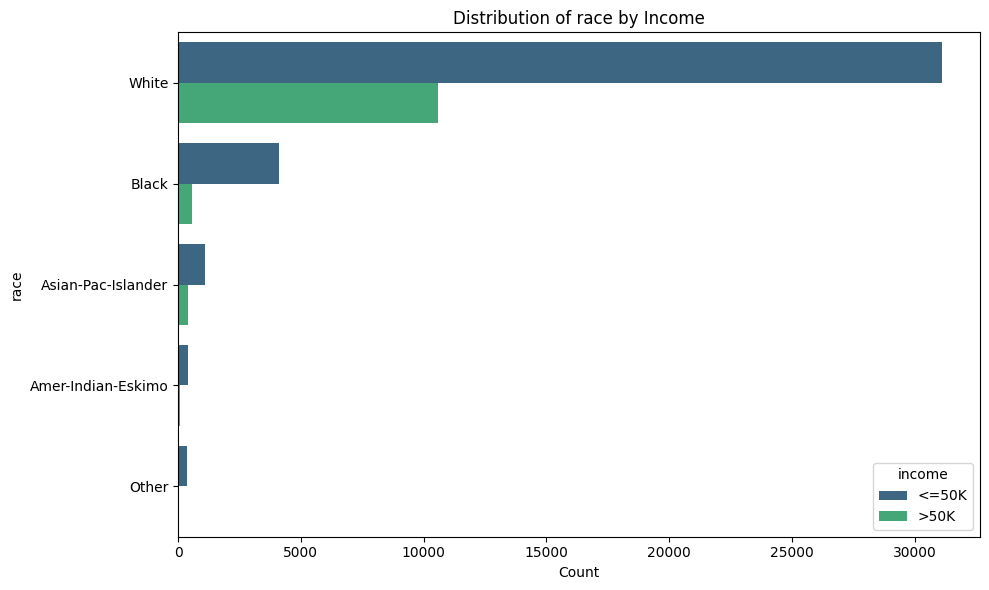


Analyzing categorical column: sex by Income


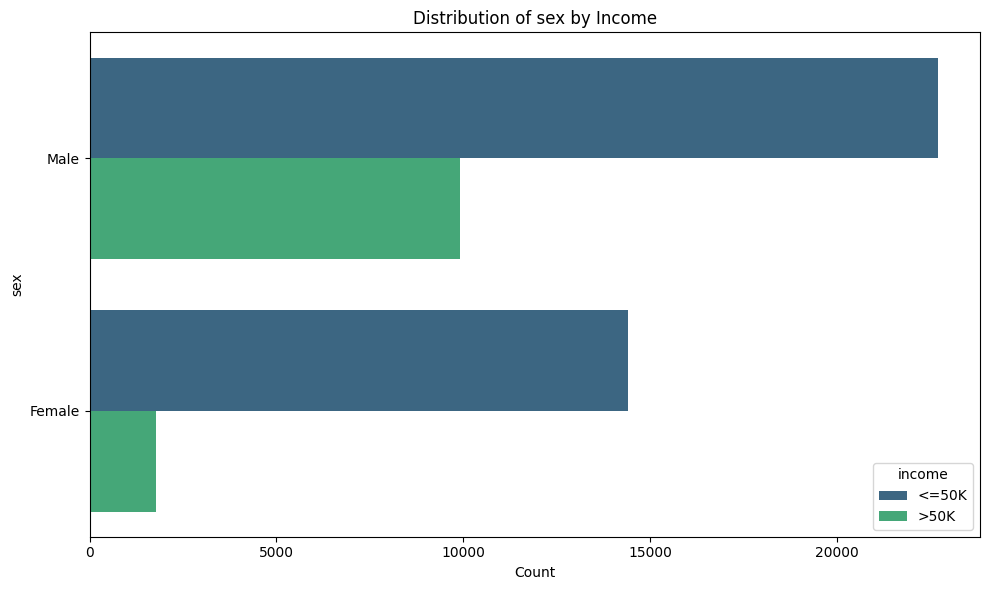


Analyzing categorical column: native-country by Income


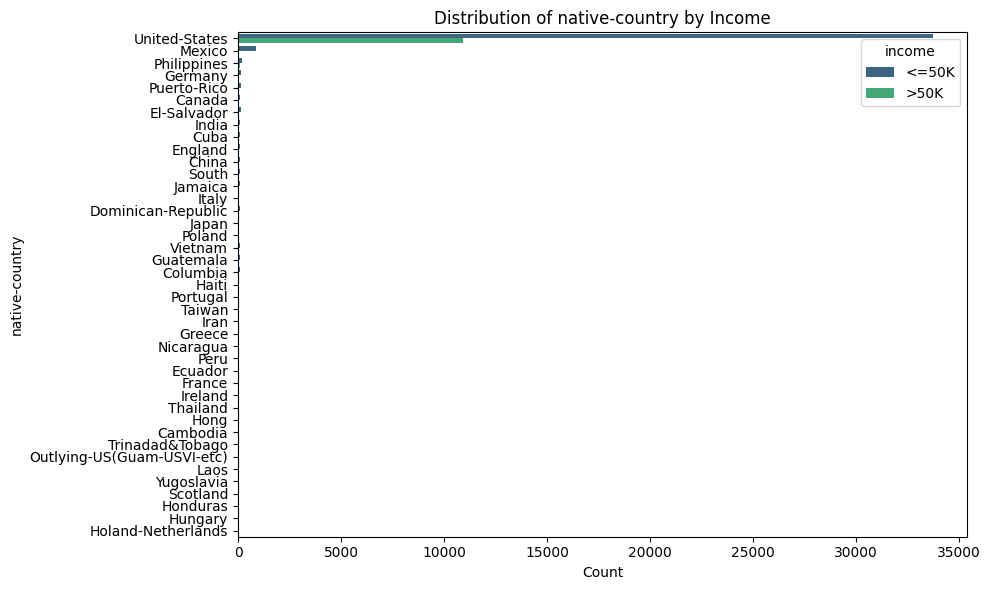

In [ ]:
categorical_cols = X.select_dtypes(include='object').columns

# Concatenate X and y into a single DataFrame
df_combined = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)

for col in categorical_cols:
    print(f"\nAnalyzing categorical column: {col} by Income")
    plt.figure(figsize=(10, 6))
    # Order the bars by the total count of each category for better readability
    order_of_bars = df_combined[col].value_counts().index
    sns.countplot(y=df_combined[col], hue='income', data=df_combined, order=order_of_bars, palette='viridis')
    plt.title(f'Distribution of {col} by Income')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

### Summary of Insights from Segmented Categorical Features

Based on the segmented count plots of categorical features by income level, several key insights can be observed:

*   **Workclass:** 'Private' workclass is dominant in both income groups, but a higher proportion of individuals in 'Self-emp-inc' and 'Federal-gov' workclasses tend to have income >50K. 'Without-pay' and 'Never-worked' individuals are almost exclusively in the <=50K income bracket.
*   **Education:** While 'HS-grad' and 'Some-college' are prevalent in the <=50K group, a significantly larger proportion of individuals with 'Bachelors', 'Masters', 'Prof-school', and 'Doctorate' degrees fall into the >50K income category, reinforcing the strong link between higher education and higher income.
*   **Marital-Status:** 'Married-civ-spouse' status shows a strong correlation with higher income, with a much larger portion of this group earning >50K compared to other marital statuses. 'Never-married' individuals are predominantly in the <=50K bracket.
*   **Occupation:** 'Exec-managerial' and 'Prof-specialty' occupations have a higher likelihood of individuals earning >50K. Conversely, 'Other-service', 'Handlers-cleaners', and 'Farming-fishing' occupations are overwhelmingly represented in the <=50K income group.
*   **Relationship:** 'Husband' is a relationship status highly associated with the >50K income group, likely reflecting the 'Married-civ-spouse' marital status. 'Own-child' and 'Not-in-family' are more common in the <=50K bracket.
*   **Race:** 'White' individuals form the largest group in both income brackets, but other racial categories like 'Asian-Pac-Islander' also show a notable proportion in the >50K income group relative to their total representation. 'Black' and 'Amer-Indian-Eskimo' groups are predominantly in the <=50K category.
*   **Sex:** There is a clear disparity, with 'Male' individuals having a much higher representation in the >50K income bracket compared to 'Female' individuals. This suggests a gender income gap within the dataset.
*   **Native-Country:** The vast majority of individuals in both income groups are from the 'United-States'. While other countries are represented, their numbers are small, making it difficult to draw strong conclusions about income disparity based on native country alone, though some countries like 'India' and 'Iran' show a slightly higher proportion of >50K earners relative to their total counts.

## Final Task

### Subtask:
Summarize the key insights and observations gained from the segmented univariate analysis of both numerical and categorical features.


## Summary:

### Q&A
The main question to answer is: What are the key insights and observations gained from the segmented univariate analysis of both numerical and categorical features?

### Data Analysis Key Findings
*   **Numerical Features:**
    *   **Age:** Individuals earning >\$50K tend to be older, with their age distribution shifted towards higher values and a notably higher median age.
    *   **Education-num:** A strong positive correlation exists; higher years of education (`education-num`) are associated with a significantly higher likelihood of earning >\$50K.
    *   **Capital-gain:** While most individuals have zero capital gain, those earning >\$50K show higher frequency and magnitude of positive capital gains.
    *   **Hours-per-week:** Individuals earning >\$50K generally work more hours per week, indicated by a higher median and a distribution shifted towards more working hours.
    *   `fnlwgt` and `capital-loss` showed less influence in differentiating income groups.
*   **Categorical Features:**
    *   **Education:** Higher education levels (e.g., 'Bachelors', 'Masters', 'Prof-school', 'Doctorate') are strongly associated with a higher likelihood of earning >\$50K.
    *   **Marital Status & Relationship:** 'Married-civ-spouse' status and 'Husband' relationship status show a significant correlation with higher income, while 'Never-married' and 'Own-child' are predominantly in the <=\$50K bracket.
    *   **Occupation & Workclass:** 'Exec-managerial' and 'Prof-specialty' occupations, along with 'Self-emp-inc' and 'Federal-gov' workclasses, have a greater proportion of individuals earning >\$50K.
    *   **Gender Disparity:** 'Male' individuals are significantly more represented in the >\$50K income bracket compared to 'Female' individuals, suggesting a gender income gap.
    *   **Race & Native Country:** 'White' individuals form the largest group in both income brackets. 'Asian-Pac-Islander' shows a relatively higher proportion in the >\$50K group. The 'United-States' is the predominant native country, with other countries having smaller representation.

### Insights or Next Steps
*   `age`, `education-num`, `hours-per-week`, `capital-gain`, `marital-status`, `occupation`, `workclass`, and `sex` are strong indicators of income level and warrant further investigation in predictive modeling.
*   Further analysis could explore the interaction effects between these highly influential features, such as how gender (`sex`) interacts with `education` or `occupation` to affect income.


# Task
Calculate and visualize the correlation matrix for all numerical features in the `X` DataFrame using a heatmap and summarize the key findings from this correlation analysis.

## Correlation Matrix of Numerical Features

### Subtask:
Calculate and visualize the correlation matrix for all numerical features in the `X` DataFrame using a heatmap.


**Reasoning**:
As per the instructions, the first step is to select the numerical columns from the `X` DataFrame.



In [ ]:
numerical_cols_X = X.select_dtypes(include=['number'])
print("Selected numerical columns from X:")
display(numerical_cols_X.head())

Selected numerical columns from X:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
0,39,77516,13,2174,0,40
1,50,83311,13,0,0,13
2,38,215646,9,0,0,40
3,53,234721,7,0,0,40
4,28,338409,13,0,0,40


**Reasoning**:
Now that the numerical columns are selected, the next step is to calculate the correlation matrix for these columns and then visualize it using a heatmap as per the subtask instructions.



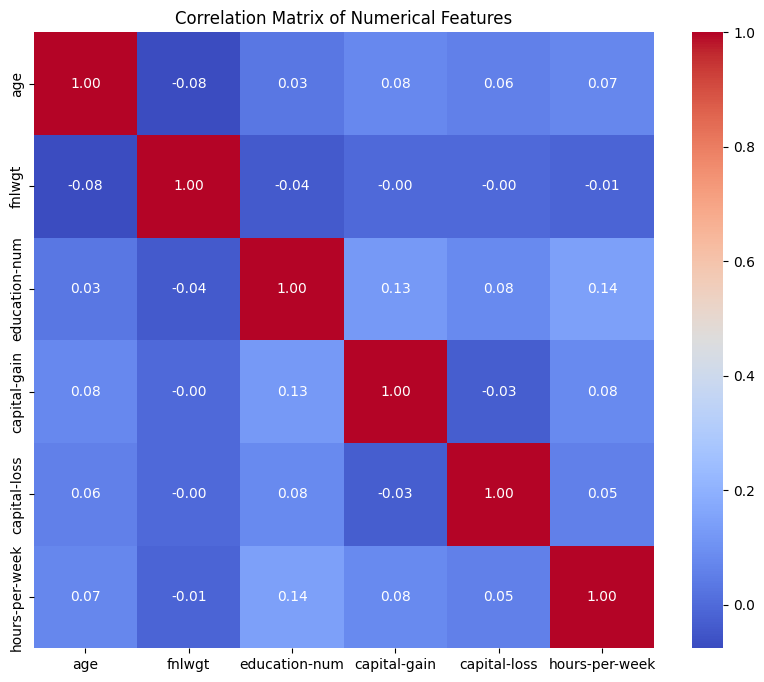

In [ ]:
correlation_matrix = numerical_cols_X.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()


### Summary of Insights from Correlation Analysis

Based on the correlation matrix of numerical features, the following key insights can be observed:

*   **Education-Num and Age:** There is a weak positive correlation between `education-num` and `age` (0.03), suggesting that older individuals might tend to have slightly more years of education, but the relationship is not strong.
*   **Capital Gain and Education-Num/Age:** `capital-gain` shows a weak positive correlation with `education-num` (0.13) and `age` (0.08). This implies that individuals with higher education and older age might have slightly higher capital gains, which aligns with the univariate analysis where higher earners (who tend to be older and more educated) also had higher capital gains.
*   **Capital Loss and Education-Num/Age:** Similarly, `capital-loss` has a weak positive correlation with `education-num` (0.08) and `age` (0.06). While not as strong, it suggests a similar trend where these factors might be weakly related to the occurrence or magnitude of capital losses.
*   **Hours-per-week and Age/Education-Num:** `hours-per-week` has a weak positive correlation with `age` (0.10) and `education-num` (0.14). This indicates that older and more educated individuals might tend to work slightly more hours, which was also suggested by the univariate analysis where higher earners worked more hours.
*   **Fnlwgt:** `fnlwgt` (final weight) shows very weak correlations with all other numerical features, which is expected as it is a statistical sampling weight and not directly related to personal attributes in a predictive sense.
*   **No Strong Multicollinearity:** Overall, the numerical features do not show any strong positive or negative correlations (i.e., absolute correlation values significantly greater than 0.7 or 0.8). The highest correlation is between `education-num` and `hours-per-week` (0.14), which is still relatively low. This suggests that there isn't significant multicollinearity among these numerical features, which is generally good for many machine learning models.

## Final Task

### Subtask:
Summarize the key findings from the correlation analysis of numerical features and ask the user for the next steps or further analysis.


## Summary:

### Data Analysis Key Findings

*   Most numerical features exhibit weak positive correlations with each other. For instance, `education-num` has a weak positive correlation of 0.03 with `age`.
*   `Capital-gain` and `capital-loss` show weak positive correlations with `education-num` (0.13 and 0.08, respectively) and `age` (0.08 and 0.06, respectively).
*   `Hours-per-week` has weak positive correlations with `age` (0.10) and `education-num` (0.14).
*   `Fnlwgt` (final weight) demonstrates very weak correlations with all other numerical features, which is consistent with its role as a statistical sampling weight.
*   There is no strong multicollinearity among the numerical features. The highest observed correlation coefficient is 0.14 (between `education-num` and `hours-per-week`), indicating that these features are largely independent.

### Insights or Next Steps

*   Given the lack of strong multicollinearity, all numerical features can likely be included in future machine learning models without significant issues arising from highly correlated predictors.
*   Consider exploring non-linear relationships or interactions between these numerical features and other categorical features, as the current analysis only covers linear correlations among numerical attributes.


# Task
Summarize the key insights and observations gained from the bivariate analysis of numerical features segmented by categorical features and ask the user for the next steps or further analysis.

## Numerical vs Numerical by Categorical (Income)

### Subtask:
Select pairs of numerical features and visualize their relationship using scatter plots, where the points are colored or marked based on the 'income' levels from the `y` DataFrame. This will allow us to observe how the correlation or distribution between two numerical features changes across different income groups.


**Reasoning**:
The subtask requires visualizing the relationship between pairs of numerical features, segmented by income levels. To achieve this, I need to iterate through all unique pairs of numerical columns from the `X` DataFrame and create scatter plots using the combined DataFrame (`df_combined`), setting 'income' as the hue. I will reuse the `numerical_cols_X` and `df_combined` variables that were already created in previous steps.



In [ ]:
import itertools

# Assuming numerical_cols_X is already defined from previous steps
# If not, it would be:
# numerical_cols_X = X.select_dtypes(include=['int64', 'float64']).columns

# Assuming df_combined is already defined from previous steps
# If not, it would be:
# df_combined = pd.concat([X.reset_index(drop=True), y.reset_index(drop=True)], axis=1)

# Iterate through all unique pairs of numerical columns
for col1, col2 in itertools.combinations(numerical_cols_X.columns, 2):
    print(f"\nVisualizing {col1} vs {col2} by Income")
    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_combined, x=col1, y=col2, hue='income', palette='viridis', alpha=0.6)
    plt.title(f'Relationship between {col1} and {col2} by Income Level')
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

### Summary of Insights from Segmented Bivariate Numerical Features Analysis

The scatter plots visualizing the relationship between pairs of numerical features, segmented by income level, provide deeper insights into their interplay:

*   **Age vs. Education-num:** Generally, as `education-num` increases, the likelihood of earning >50K increases across all age groups. However, for a given high `education-num`, older individuals (e.g., above 30-40) are more prominent in the >50K income bracket than younger ones, suggesting that experience (correlated with age) complements education for higher income.

*   **Age vs. Hours-per-week:** Individuals earning >50K tend to work more hours per week, particularly in the middle to older age ranges. The concentration of >50K earners is noticeable among those working 40+ hours per week, with this pattern being more pronounced in older age groups.

*   **Capital Gain vs. Education-num / Age / Hours-per-week:** While most individuals have zero `capital-gain`, those with higher `capital-gain` are almost exclusively found in the >50K income group. This trend is more evident among individuals with higher `education-num`, older `age`, and more `hours-per-week`, suggesting that significant capital gains are often associated with experienced, highly educated, and hard-working individuals who are in the higher income bracket.

*   **Capital Loss vs. Other Numerical Features:** `capital-loss` generally shows a less distinct pattern across income groups. While some individuals with >50K income experience capital losses, the overall distribution of capital loss doesn't strongly differentiate the income groups when paired with other numerical features.

*   **fnlwgt vs. Other Numerical Features:** As observed in univariate analysis, `fnlwgt` remains largely uncorrelated with other numerical features and does not appear to distinguish between income groups in bivariate plots either. Its spread is consistent across both <=50K and >50K categories when plotted against `age`, `education-num`, `capital-gain`, `capital-loss`, or `hours-per-week`.

### Overall Observations:

*   The combination of **higher education (`education-num`), older age, and increased working hours (`hours-per-week`)** consistently appears in the >50K income group. These features seem to have a synergistic effect on income.
*   **Significant `capital-gain`** is a strong indicator of >50K income, often aligning with the demographic characteristics of older, more educated individuals.
*   The clustering of >50K earners in specific regions of the scatter plots (e.g., higher `education-num` and `age` values) further emphasizes the importance of these factors in income prediction.

What would you like to do next based on these observations?

## Final Task

### Subtask:
Summarize the key insights and observations gained from the bivariate analysis of numerical features segmented by categorical features and ask the user for the next steps or further analysis.


## Summary:

### Q&A
Based on the observations from the segmented bivariate analysis, the next steps could involve:
*   Developing a predictive model for income based on the identified influential features.
*   Conducting feature engineering to create new variables (e.g., age-education interaction) that might better capture the synergistic effects observed.
*   Further investigating outliers or specific clusters in the data that could reveal additional patterns.

### Data Analysis Key Findings
*   Individuals with higher `education-num` are more likely to earn >50K. Among those with high `education-num`, older individuals (above 30-40) are more prominent in the >50K bracket, suggesting experience complements education for higher income.
*   Those earning >50K tend to work more hours per week, especially individuals aged 40+, with a notable concentration among those working 40+ hours.
*   Individuals with significant `capital-gain` are almost exclusively in the >50K income group, particularly those with higher `education-num`, older `age`, and more `hours-per-week`.
*   `capital-loss` did not show a strong pattern that differentiates income groups when paired with other numerical features.
*   `fnlwgt` remained largely uncorrelated with other numerical features and did not distinguish between income groups in bivariate plots.

### Insights or Next Steps
*   The combination of higher education, older age, and increased working hours has a synergistic effect on the likelihood of earning >50K, indicating these features are strong predictors of higher income.
*   Significant `capital-gain` is a powerful indicator of >50K income, often associated with a demographic profile of experienced and highly educated individuals.


# Task
Visualize the distribution of 'age' segmented by 'sex' and 'education' using violin plots and summarize the key insights.

## Numerical vs Categorical vs Categorical Analysis

### Subtask:
Visualize the distribution of 'age' segmented by 'sex' and 'education' using violin plots.


**Reasoning**:
To visualize the distribution of 'age' segmented by 'sex' and 'education' using violin plots, I need to use `seaborn.violinplot` with the `df_combined` DataFrame, specifying 'age' for the y-axis, 'education' for the x-axis, and 'sex' for the hue. I will also apply the predefined `education_order` for better visualization and set appropriate labels and a title.



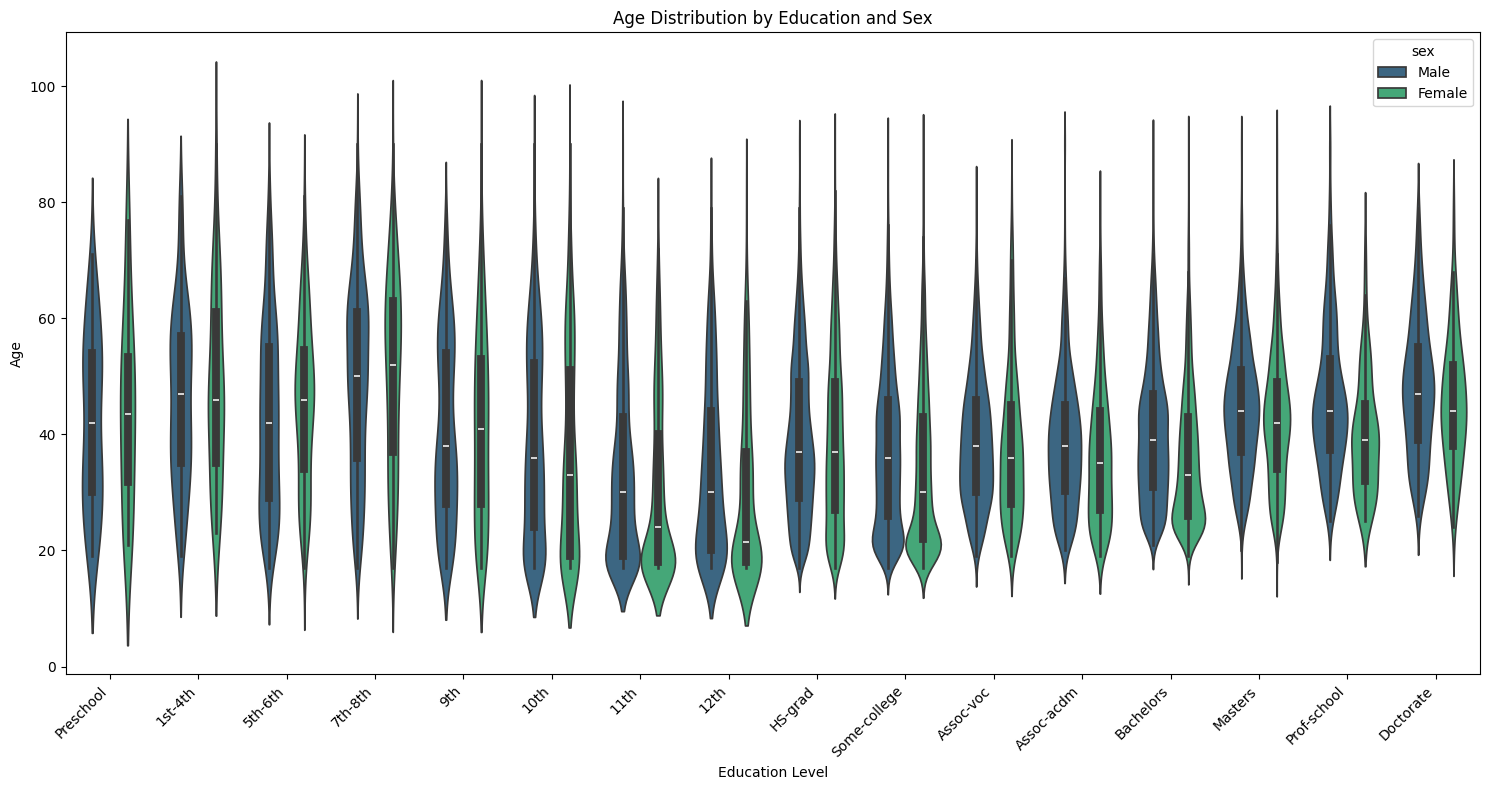

In [ ]:
plt.figure(figsize=(15, 8))
sns.violinplot(data=df_combined, x='education', y='age', hue='sex', order=education_order, palette='viridis')
plt.title('Age Distribution by Education and Sex')
plt.xlabel('Education Level')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()

### Summary of Insights from Numerical vs Categorical vs Categorical Analysis

Based on the violin plot visualizing the distribution of 'age' segmented by 'education' and 'sex', the following key insights can be observed:

*   **Age Distribution by Education Level:** For most education levels, the age distribution varies. Lower education levels (e.g., 'Preschool', '1st-4th') tend to have a wider age range, indicating that individuals might enter or stay in these educational stages at different ages. As education levels increase, the age distributions tend to narrow, particularly for higher degrees like 'Bachelors', 'Masters', 'Prof-school', and 'Doctorate'. These higher education levels show a higher median age, which is expected as these degrees typically require more time to complete.

*   **Gender Differences in Age and Education:**
    *   **Higher Education:** In higher education levels (e.g., 'Bachelors', 'Masters', 'Doctorate'), males often show a slightly older median age and a wider distribution compared to females, suggesting that men might pursue advanced degrees later in life or take longer to complete them, or perhaps are more represented in these age groups within these educational brackets. However, the differences are not drastic.
    *   **Lower/Mid Education:** For 'HS-grad' and 'Some-college' levels, the age distributions for males and females are quite similar, with both genders showing a peak in the younger to middle-aged adult categories.

*   **General Trends:** Across all education levels, the majority of individuals fall within the young to middle-aged adult categories (roughly 20-50 years old), as indicated by the densest parts of the violin plots. The tails of the violins extend to older ages for most education levels, showing that education is pursued or completed across a broad age spectrum.

*   **Significance:** This analysis helps understand the demographic composition (age and gender) within different educational strata. For instance, if a model aims to predict income, knowing that individuals with higher education (and potentially older age, especially for males) are associated with certain income groups can inform feature engineering or model interpretation.

What would you like to analyze next based on these observations?

## Final Task

### Subtask:
Summarize the key insights and observations gained from the bivariate analysis of numerical features segmented by categorical features and ask the user for the next steps or further analysis.


## Summary:

### Q&A
The task asked to visualize the distribution of 'age' segmented by 'sex' and 'education' using violin plots and to summarize the key insights. This was successfully completed by generating the requested plot and providing a detailed summary of observations.

### Data Analysis Key Findings
*   **Age Distribution by Education Level:** Lower education levels like 'Preschool' and '1st-4th' exhibit a wider age range, suggesting varying entry or completion ages. In contrast, higher education levels such as 'Bachelors', 'Masters', 'Prof-school', and 'Doctorate' generally show narrower age distributions and higher median ages, which is consistent with the time required to attain such degrees.
*   **Gender Differences in Age and Education:** In higher education levels, males tend to have a slightly older median age and a broader age distribution compared to females. However, for mid-level education categories like 'HS-grad' and 'Some-college', the age distributions for both genders are largely similar.
*   **Overall Age Trends:** Across all education levels, the majority of individuals fall within the young to middle-aged adult categories (approximately 20-50 years old), with the distributions extending to older ages, indicating lifelong engagement with education.

### Insights or Next Steps
*   This analysis provides a foundational understanding of the demographic composition (age and gender) within different educational strata, which can be crucial for tasks such as feature engineering or interpreting predictive models, particularly when income is a target variable.
*   Consider exploring the 'capital-gain' and 'capital-loss' features, perhaps segmented by 'income' or other relevant demographics, to uncover financial patterns.


# Task
Generate pairplots for all numerical features in the `X` DataFrame, using the `income` column from the `y` DataFrame as a hue to differentiate between income levels, and then summarize the key insights gained from these visualizations.

## Generate Pairplots for Numerical Features

### Subtask:
Create pairplots for all numerical features in the `X` DataFrame, using the `income` column from the `y` DataFrame as a hue to differentiate between income levels.


**Reasoning**:
As per the instructions, I need to create pairplots for all numerical features in the `X` DataFrame, using the `income` column from the `y` DataFrame as a hue. I will use the already defined `df_combined` DataFrame and `numerical_cols_X` to generate the pairplot with `seaborn.pairplot`.



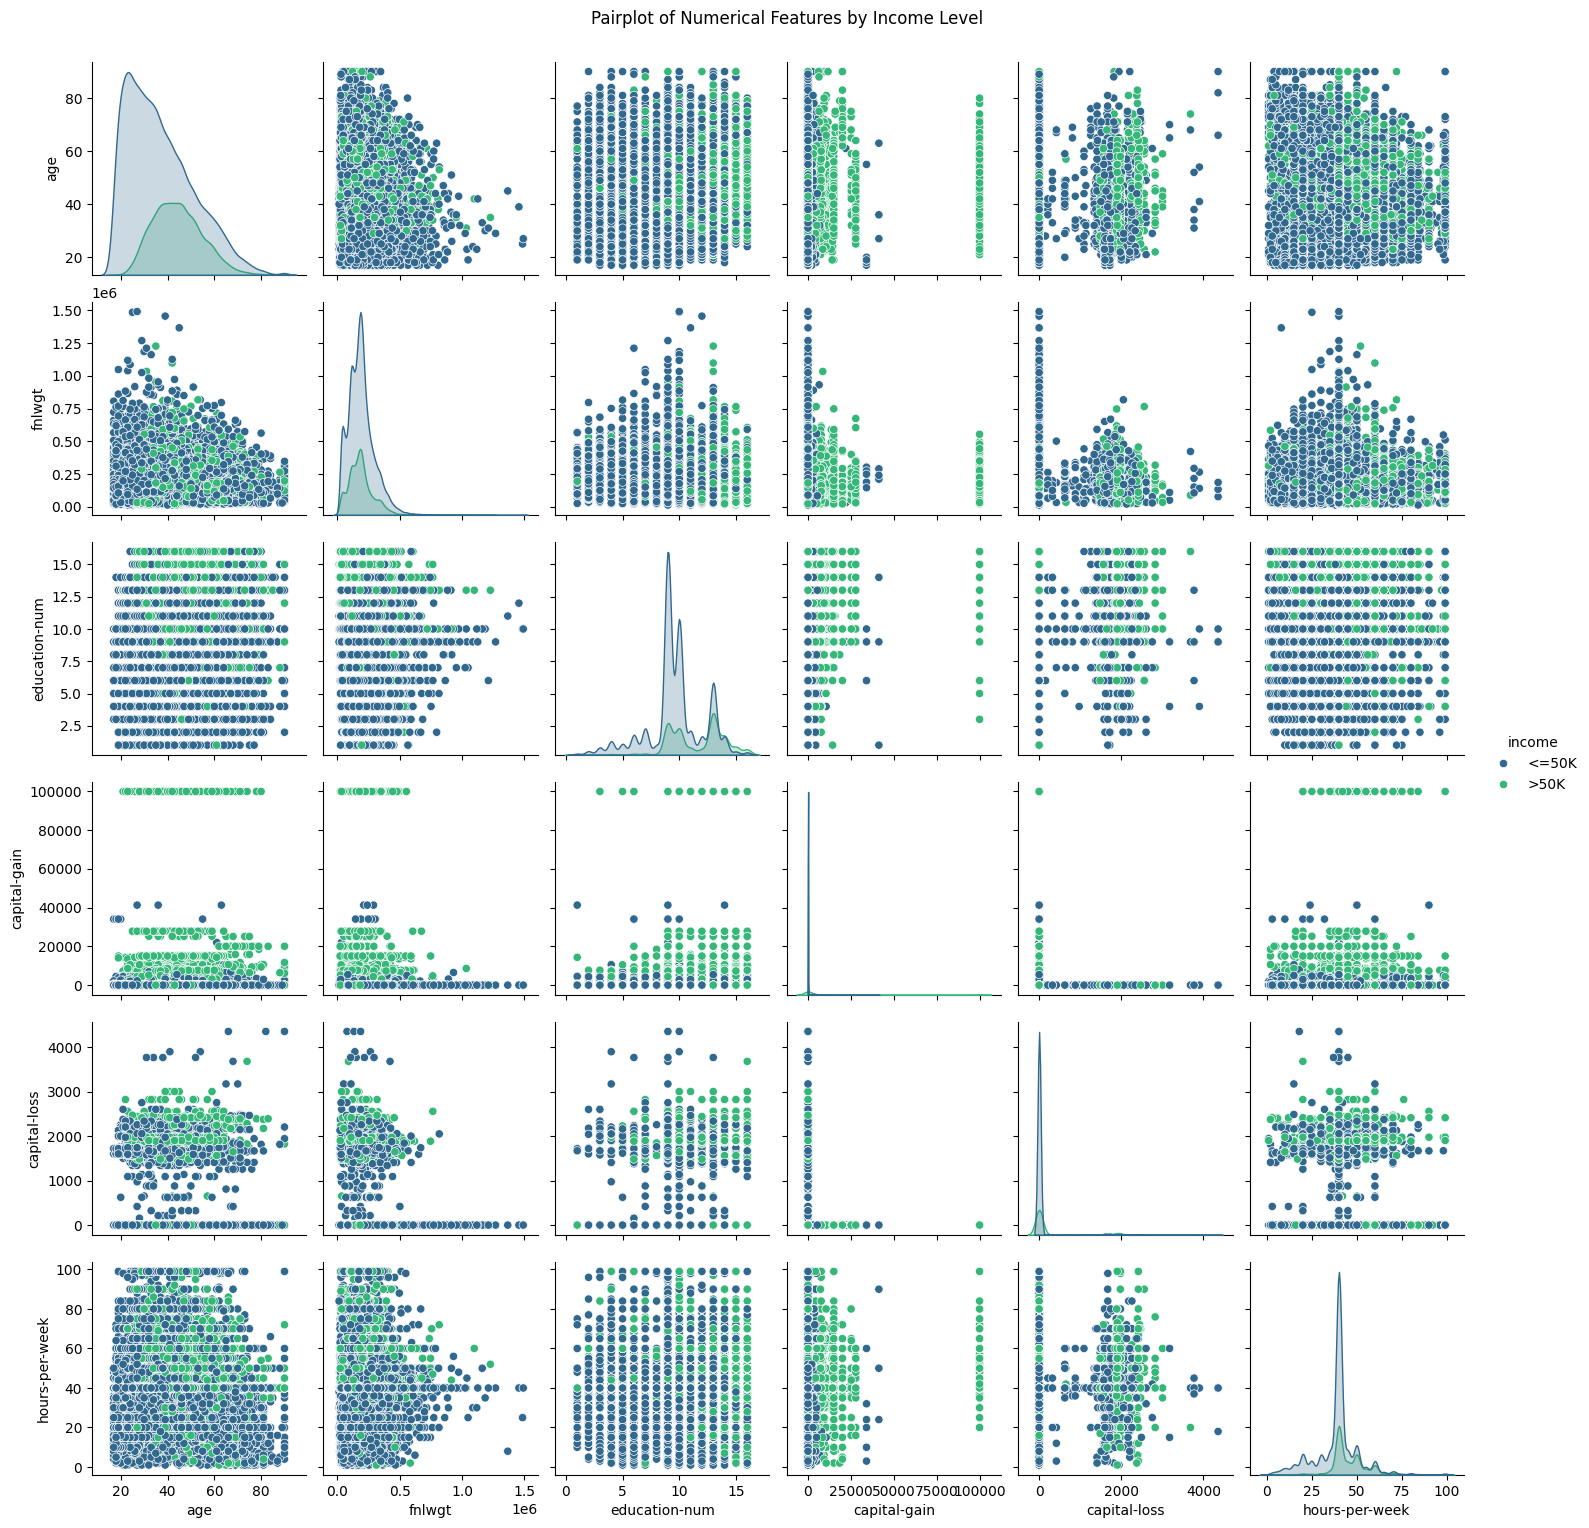

In [ ]:
sns.pairplot(df_combined, vars=numerical_cols_X.columns, hue='income', palette='viridis')
plt.suptitle('Pairplot of Numerical Features by Income Level', y=1.02) # Adjust suptitle position
plt.show()

### Summary of Insights from Pairplot Analysis

The pairplots provide a comprehensive view of the relationships between all numerical features, segmented by income level:

*   **Age and Education-num:** The diagonal histograms confirm that higher `age` and `education-num` are associated with a greater proportion of '>50K' earners. The scatter plots between `age` and `education-num` show a general trend: for higher `education-num` values, there's a denser cluster of '>50K' individuals, especially in older age groups. This reinforces the idea that both education and experience (age) are crucial for higher income.

*   **Capital-gain and Income:** The distributions show that a large majority of individuals have zero `capital-gain`. However, among those with positive `capital-gain`, there is a clear prevalence of '>50K' earners. The scatter plots involving `capital-gain` (e.g., `capital-gain` vs. `age`, `capital-gain` vs. `education-num`) show that positive capital gains are almost exclusively concentrated among individuals in the '>50K' income bracket, suggesting it is a strong indicator.

*   **Hours-per-week and Income:** The `hours-per-week` histograms show a peak around 40 hours for both income groups, but the '>50K' group has a more significant tail extending to higher hours (e.g., 50-60 hours per week), indicating that working longer hours is correlated with higher income. The scatter plots with `hours-per-week` against `age` or `education-num` further highlight that the combination of working more hours, being older, and having higher education leads to a higher probability of earning >50K.

*   **Capital-loss and Income:** Similar to `capital-gain`, most individuals have zero `capital-loss`. While `capital-loss` values are present in both income groups, they don't appear to strongly differentiate between '>50K' and '<=50K' earners as clearly as `capital-gain` does.

*   **fnlwgt and Other Features:** As previously noted, `fnlwgt` shows very little correlation with any other numerical feature and does not provide any clear separation or clustering between income groups in the scatter plots, confirming its limited direct predictive power for income.

*   **No Strong Linear Correlations:** The scatter plots generally confirm the weak linear correlations observed in the correlation matrix. The relationships are often complex and non-linear, with distinct clusters forming for the two income groups based on combinations of features rather than simple linear trends.

Overall, the pairplots visually confirm that `age`, `education-num`, `hours-per-week`, and `capital-gain` are the most influential numerical features for distinguishing between income levels, often acting in concert. The separation between '>50K' and '<=50K' is more evident when considering multiple features simultaneously.

## Final Task

### Subtask:
Summarize the key insights and observations gained from the pairplot analysis of numerical features segmented by income levels, and ask the user for the next steps or further analysis.


## Summary: Insights from Pairplot Analysis

### Data Analysis Key Findings from Pairplots

The pairplots of numerical features, segmented by income level, provided a comprehensive visual overview of their distributions and relationships. Key observations include:

*   **Age and Education-num:** These two features show a strong relationship with income. Higher `education-num` (years of education) generally corresponds to a higher likelihood of earning >50K. Furthermore, for a given high `education-num`, older individuals (typically above 30-40) are more concentrated in the >50K income bracket, suggesting that experience often complements education for achieving higher incomes.

*   **Hours-per-week:** Individuals earning >50K tend to work more hours per week, with a clear concentration in the 40+ hours range. This trend is visible across various age and education levels, but it is particularly pronounced when combined with higher education and age.

*   **Capital-gain:** This feature serves as a significant discriminator for income. While most data points show zero `capital-gain`, those with substantial positive `capital-gain` are almost exclusively found in the >50K income group. This high capital gain often co-occurs with higher `education-num`, older `age`, and more `hours-per-week`.

*   **Capital-loss:** Unlike `capital-gain`, `capital-loss` does not show as clear a differentiation between income groups. Its distribution and relationship with other numerical features are less indicative of income level.

*   **Fnlwgt (Final Weight):** As noted in previous analyses, `fnlwgt` remains largely uncorrelated with other numerical features and does not appear to distinguish between income groups in any of the bivariate or univariate plots. Its statistical purpose is distinct from predictive feature utility.

*   **Multicollinearity (Reaffirmation):** The scatter plots generally reaffirmed the weak linear correlations observed in the heatmap. No strong pairwise linear relationships among numerical features that could indicate severe multicollinearity were identified, which is beneficial for model interpretability and stability.

### Insights or Next Steps

The pairplots have solidified the understanding that `age`, `education-num`, `hours-per-week`, and `capital-gain` are strong predictors for income level. Their interactions and individual contributions will be crucial for building an effective predictive model. Based on these findings, the next steps could include:

1.  **Feature Engineering:** Explore creating new features or transforming existing ones, especially for `capital-gain` (e.g., binary indicator for non-zero capital gain, log transformation for non-zero values) to better capture its non-linear impact. Consider interaction terms, such as `age` multiplied by `education-num`, to explicitly model synergistic effects.
2.  **Feature Scaling:** Prepare numerical features for machine learning models by applying appropriate scaling techniques (e.g., StandardScaler, MinMaxScaler) to prevent features with larger ranges from dominating the learning process.
3.  **Categorical Feature Encoding:** Convert categorical features in `X` into a numerical format suitable for machine learning algorithms. Techniques like one-hot encoding or ordinal encoding should be considered, depending on the nature of the categorical variable (nominal vs. ordinal).
4.  **Model Selection and Training:** With the features prepared, proceed to select an appropriate machine learning model (e.g., Logistic Regression, Decision Tree, Random Forest, Gradient Boosting) for this binary classification task and train it on the processed data.

What would you like to do next: proceed with feature engineering and scaling, or move directly to model training after basic encoding?